# 📈 Wang & Yan (2023) — SP500 H1 — Rééchantillonnage depuis M5
## Split 70/15/15 + Toutes les variables + Hyperparamètre Tuning + Seuil Optimal + Simulation Réaliste

### Objectif :
Ce notebook rééchantillonne les données M5 en **H1 (1 heure)** pour comparer les performances
avec le notebook M5 et évaluer l'impact du timeframe sur la qualité prédictive.

### Pipeline :
```
Données M5 → Rééchantillonnage OHLCV en H1
                    ↓
TRAIN (70%) → Construction features → Standardisation
                    ↓
RandomizedSearchCV + TimeSeriesSplit → Meilleurs hyperparamètres
                    ↓
VALIDATION (15%) → Optimisation seuil
                    ↓
TEST (15%) → Évaluation finale → Simulation trading
```

## 0. Imports & Paramètres

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from joblib import Parallel, delayed


from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    AdaBoostRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid')

# ── Paramètres MA ─────────────────────────────────────────────────────────
MA_COURT   = 5
MA_LONG    = 20
FAST_EMA   = 12 ; SLOW_EMA = 26 ; SIGNAL_EMA = 9
RSI_P      = 12
ROC_SHORT  = 5  ; ROC_LONG  = 20
MOM_P      = 5
STOCH_P    = 9

# ── Split 70 / 15 / 15 ────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Tuning ────────────────────────────────────────────────────────────────
N_ITER_SEARCH = 30
N_CV_FOLDS    = 5
N_TUNING      = 5_000   # H1 : dataset plus petit


# ── Broker SP500 ───────────────────────────────────────────────────────────
SPREAD_USD       = 0.60
SWAP_LONG_PCT    = -0.01703 / 100
SWAP_SHORT_PCT   =  0.00314 / 100
CAPITAL_INIT     = 100_000
BOUGIES_PAR_AN   = 252 * 6   # H1 : ~6 bougies par jour de trading

print('✅ Imports OK')
print(f'   Split  : Train={int(TRAIN_RATIO*100)}% | Val={int(VAL_RATIO*100)}% | Test={int(TEST_RATIO*100)}%')
print(f'   Tuning : {N_ITER_SEARCH} combinaisons × {N_CV_FOLDS} folds TimeSeriesSplit')
print(f'   Broker : Spread={SPREAD_USD} USD | Capital={CAPITAL_INIT:,} USD')

✅ Imports OK
   Split  : Train=70% | Val=15% | Test=15%
   Tuning : 30 combinaisons × 5 folds TimeSeriesSplit
   Broker : Spread=0.6 USD | Capital=100,000 USD


## 1. Chargement & Rééchantillonnage M5 → H1

In [5]:
DATA_DIR = Path('../SCR/data')

# ── Chargement des données M5 ─────────────────────────────────────────────
sp500_m5 = pd.read_csv(DATA_DIR / 'sp500_m5.csv', index_col='time', parse_dates=True)
sp500_m5 = sp500_m5.sort_index()
sp500_m5 = sp500_m5[~sp500_m5.index.duplicated(keep='first')]
sp500_m5.columns = [c.lower() for c in sp500_m5.columns]
sp500_m5 = sp500_m5.dropna(subset=['close'])

if 'tick_volume' in sp500_m5.columns:
    sp500_m5.rename(columns={'tick_volume': 'volume'}, inplace=True)

print(f'✅ Données M5 chargées : {len(sp500_m5):,} bougies')

# ── Rééchantillonnage M5 → H1 ─────────────────────────────────────────────
# OHLCV standard : open=premier, high=max, low=min, close=dernier, volume=somme
df = sp500_m5.resample('1h').agg({
    'open'  : 'first',
    'high'  : 'max',
    'low'   : 'min',
    'close' : 'last',
    'volume': 'sum'
}).dropna()

print(f'✅ Rééchantillonnage M5 → H1 : {len(df):,} bougies H1')
print(f'   Période : {df.index.min()} → {df.index.max()}')
print(f'   Ratio   : {len(sp500_m5):,} bougies M5 → {len(df):,} bougies H1 (÷{len(sp500_m5)//len(df)})')
df.head(3)

✅ Données M5 chargées : 99,999 bougies
✅ Rééchantillonnage M5 → H1 : 8,346 bougies H1
   Période : 2024-11-14 15:00:00+00:00 → 2026-04-17 23:00:00+00:00
   Ratio   : 99,999 bougies M5 → 8,346 bougies H1 (÷11)


,open,high,low,close,volume
time,,,,,
2024-11-14 15:00:00+00:00,5995.33,5996.00,5981.72,5986.56,2168
2024-11-14 16:00:00+00:00,5986.81,5993.04,5972.65,5978.86,4512
2024-11-14 17:00:00+00:00,5978.73,5985.22,5967.11,5977.39,5410


## 2. Features & Variable Cible

In [6]:
feat = df.copy()
c = feat['close'] ; h = feat['high'] ; l = feat['low'] ; v = feat['volume']

# ── Prix bruts ────────────────────────────────────────────────────────────
feat['close_1']    = c.shift(1)
feat['close_incr'] = c - c.shift(1)

# ── MA5 et MA20 ───────────────────────────────────────────────────────────
feat['ma5']        = c.rolling(MA_COURT).mean()
feat['ma5_1']      = feat['ma5'].shift(1)
feat['ma5_incr']   = feat['ma5'] - feat['ma5_1']
feat['ma20']       = c.rolling(MA_LONG).mean()
feat['ma20_1']     = feat['ma20'].shift(1)
feat['ma20_incr']  = feat['ma20'] - feat['ma20_1']
feat['ma5_20']     = feat['ma5'] - feat['ma20']

# ── MACD ─────────────────────────────────────────────────────────────────
ema12               = c.ewm(span=FAST_EMA,   adjust=False).mean()
ema26               = c.ewm(span=SLOW_EMA,   adjust=False).mean()
feat['macd']        = ema12 - ema26
feat['macd_signal'] = feat['macd'].ewm(span=SIGNAL_EMA, adjust=False).mean()
feat['macd_hist']   = feat['macd'] - feat['macd_signal']

# ── Momentum, ROC ────────────────────────────────────────────────────────
feat['mom']   = c - c.shift(MOM_P)
feat['roc_5'] = (c - c.shift(ROC_SHORT)) / c.shift(ROC_SHORT)
feat['roc_20']= (c - c.shift(ROC_LONG))  / c.shift(ROC_LONG)

# ── RSI (vectorisé) ───────────────────────────────────────────────────────
def compute_rsi(series, period):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))
feat['rsi'] = compute_rsi(c, RSI_P)

# ── Stochastique ──────────────────────────────────────────────────────────
lowest_low      = l.rolling(STOCH_P).min()
highest_high    = h.rolling(STOCH_P).max()
denom           = (highest_high - lowest_low).replace(0, np.nan)
feat['stoch_k'] = 100 * (c - lowest_low) / denom
feat['stoch_d'] = feat['stoch_k'].rolling(3).mean()

# ── Volume ────────────────────────────────────────────────────────────────
feat['volume_1'] = v.shift(1)
feat['vol_incr'] = v - v.shift(1)

# ── OBV vectorisé ────────────────────────────────────────────────────────
price_diff = c.diff()
obv_delta  = np.where(price_diff > 0, v, np.where(price_diff < 0, -v, 0))
feat['obv'] = pd.Series(obv_delta, index=feat.index).cumsum()

# ── Variable cible ────────────────────────────────────────────────────────
feat['ma5_next'] = feat['ma5'].shift(-1)
feat['value']    = feat['ma5_next'] - feat['ma5']
feat['label']    = np.where(feat['value'] > 0, 1, -1)
feat.dropna(inplace=True)

label_counts = feat['label'].value_counts()
print(f'✅ Features + cible OK : {len(feat):,} échantillons')
print(f'   Hausse (+1) : {label_counts.get(1,0):,} ({label_counts.get(1,0)/len(feat)*100:.1f}%)')
print(f'   Baisse  (-1): {label_counts.get(-1,0):,} ({label_counts.get(-1,0)/len(feat)*100:.1f}%)')

✅ Features + cible OK : 8,325 échantillons
   Hausse (+1) : 4,520 (54.3%)
   Baisse  (-1): 3,805 (45.7%)


## 3. Split 70 / 15 / 15 chronologique

In [7]:
ALL_FEATURES = [
    'close_1','close_incr',
    'ma5','ma5_1','ma5_incr',
    'ma20','ma20_1','ma20_incr','ma5_20',
    'macd','macd_signal','macd_hist',
    'mom','roc_5','roc_20','rsi',
    'stoch_k','stoch_d',
    'volume','volume_1','vol_incr','obv',
    'open','high','low','close'
]

n         = len(feat)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train = feat.iloc[:train_end].copy()
val   = feat.iloc[train_end:val_end].copy()
test  = feat.iloc[val_end:].copy()

print(f'✅ Split 70/15/15 chronologique')
print(f'   Train      : {len(train):,} | {train.index.min().date()} → {train.index.max().date()}')
print(f'   Validation : {len(val):,}  | {val.index.min().date()} → {val.index.max().date()}')
print(f'   Test       : {len(test):,}  | {test.index.min().date()} → {test.index.max().date()}')

✅ Split 70/15/15 chronologique
   Train      : 5,827 | 2024-11-15 → 2025-11-12
   Validation : 1,249  | 2025-11-12 → 2026-02-02
   Test       : 1,249  | 2026-02-02 → 2026-04-17


## 4. Standardisation sur toutes les features (26 variables)

In [8]:
FEATURE_COLS = ALL_FEATURES  # toutes les 26 variables, sans sélection VIF

# Standardisation — fit UNIQUEMENT sur train
scaler  = StandardScaler()
X_train = scaler.fit_transform(train[FEATURE_COLS])
X_val   = scaler.transform(val[FEATURE_COLS])
X_test  = scaler.transform(test[FEATURE_COLS])

y_train_reg = train['value'].values
y_val_reg   = val['value'].values
y_test_reg  = test['value'].values
y_train_clf = train['label'].values
y_val_clf   = val['label'].values
y_test_clf  = test['label'].values

print(f'✅ Standardisation OK — toutes les {len(FEATURE_COLS)} features conservées (sans sélection VIF)')
print(f'   X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}')

✅ Standardisation OK — toutes les 26 features conservées (sans sélection VIF)
   X_train : (5827, 26) | X_val : (1249, 26) | X_test : (1249, 26)


## 5. Tuning des Hyperparamètres

**Règle d'or** : le tuning se fait **uniquement sur le Train** via TimeSeriesSplit.
La **Validation** sert uniquement à sélectionner le meilleur modèle.
Le **Test** est verrouillé jusqu'à la cellule finale.

### Optimisations vitesse :
- **LinearSVR** au lieu de `SVR(kernel='linear')` → même modèle, ~100x plus rapide
- **Sous-ensemble réduit à 5 000 obs** pour le SVM (complexité quadratique O(n²))
- **n_jobs=-1** sur tous les modèles parallélisables

In [9]:
tscv   = TimeSeriesSplit(n_splits=N_CV_FOLDS)

# Sous-ensemble général pour les modèles rapides
X_tune     = X_train[-N_TUNING:]
y_tune_reg = y_train_reg[-N_TUNING:]

# Sous-ensemble réduit SPÉCIFIQUEMENT pour le SVM (complexité quadratique)
N_TUNING_SVM  = 5_000
X_tune_svm    = X_train[-N_TUNING_SVM:]
y_tune_svm    = y_train_reg[-N_TUNING_SVM:]

print(f'⚡ Tuning général    : {N_TUNING:,} bougies')
print(f'⚡ Tuning SVM        : {N_TUNING_SVM:,} bougies (LinearSVR — optimisé)')
print(f'   Features utilisées : {len(FEATURE_COLS)} (après sélection VIF)')

from sklearn.svm import LinearSVR

param_grids = {
    'Decision Tree': {
        'model'  : DecisionTreeRegressor(random_state=42),
        'params' : {
            'max_depth'        : [3, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 5],
        },
        'X_tune' : X_tune,
        'y_tune' : y_tune_reg
    },
    'SVM': {
        # LinearSVR = même modèle mathématique que SVR(kernel='linear')
        # mais implémentation liblinear, ~100x plus rapide sur grands datasets
        'model'  : LinearSVR(random_state=42, max_iter=5000, dual=True),
        'params' : {
            'C'      : [0.01, 0.1, 1, 10, 100],
            'epsilon': [0.0, 0.01, 0.1, 0.5],
        },
        'X_tune' : X_tune_svm,
        'y_tune' : y_tune_svm
    },
    'Random Forest': {
        'model'  : RandomForestRegressor(random_state=42, n_jobs=-1),
        'params' : {
            'n_estimators'    : [100, 200, 300],
            'max_depth'       : [5, 10, 20],
            'min_samples_leaf': [1, 2, 5],
            'max_features'    : ['sqrt', 'log2']
        },
        'X_tune' : X_tune,
        'y_tune' : y_tune_reg
    },
    'Bagging': {
        'model'  : BaggingRegressor(random_state=42, n_jobs=-1),
        'params' : {
            'n_estimators': [100, 200],
            'max_samples' : [0.7, 1.0],
            'max_features': [0.7, 1.0],
        },
        'X_tune' : X_tune,
        'y_tune' : y_tune_reg
    },
    'AdaBoost': {
        'model'  : AdaBoostRegressor(random_state=42),
        'params' : {
            'n_estimators' : [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.5, 1.0],
            'loss'         : ['linear', 'square']
        },
        'X_tune' : X_tune,
        'y_tune' : y_tune_reg
    }
}

reg_models  = {}
reg_results = []

print('\nTuning sur TRAIN (TimeSeriesSplit) → évaluation sur VALIDATION')
print('='*75)

for name, config in param_grids.items():
    print(f'\n🔍 {name}...')
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator           = config['model'],
        param_distributions = config['params'],
        n_iter              = 15,
        cv                  = tscv,
        scoring             = 'r2',
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 0
    )
    search.fit(config['X_tune'], config['y_tune'])

    best_model = search.best_estimator_
    best_model.fit(X_train, y_train_reg)
    reg_models[name] = best_model

    elapsed    = time.time() - t0
    y_pred_val = best_model.predict(X_val)
    r2_val     = r2_score(y_val_reg, y_pred_val)
    rmse_val   = np.sqrt(mean_squared_error(y_val_reg, y_pred_val))
    mae_val    = mean_absolute_error(y_val_reg, y_pred_val)
    acc_val    = accuracy_score(y_val_clf, np.where(y_pred_val > 0, 1, -1))

    reg_results.append({
        'Modèle'       : name,
        'R² Val'       : round(r2_val,   3),
        'RMSE Val'     : round(rmse_val, 3),
        'MAE Val'      : round(mae_val,  3),
        'Acc Val (s=0)': round(acc_val,  3),
        'Best Params'  : search.best_params_,
        'Temps (s)'    : round(elapsed,  1)
    })
    print(f'   ✅ R²={r2_val:.3f} | Acc Val={acc_val:.3f} | Temps={elapsed:.1f}s')
    print(f'   Params : {search.best_params_}')

reg_df = pd.DataFrame(reg_results)
print('\n' + '='*75)
print(f'Meilleur sur Validation (R²) : {reg_df.loc[reg_df["R² Val"].idxmax(), "Modèle"]}')
print('\n⏱️  Temps total tuning : {:.0f}s'.format(reg_df['Temps (s)'].sum()))
reg_df[['Modèle','R² Val','RMSE Val','MAE Val','Acc Val (s=0)','Temps (s)']]

⚡ Tuning général    : 5,000 bougies
⚡ Tuning SVM        : 5,000 bougies (LinearSVR — optimisé)
   Features utilisées : 26 (après sélection VIF)

Tuning sur TRAIN (TimeSeriesSplit) → évaluation sur VALIDATION

🔍 Decision Tree...
   ✅ R²=0.576 | Acc Val=0.764 | Temps=4.9s
   Params : {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 5}

🔍 SVM...
   ✅ R²=0.735 | Acc Val=0.812 | Temps=6.4s
   Params : {'epsilon': 0.5, 'C': 10}

🔍 Random Forest...
   ✅ R²=0.659 | Acc Val=0.780 | Temps=19.1s
   Params : {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20}

🔍 Bagging...
   ✅ R²=0.659 | Acc Val=0.776 | Temps=48.5s
   Params : {'n_estimators': 200, 'max_samples': 0.7, 'max_features': 1.0}

🔍 AdaBoost...
   ✅ R²=0.576 | Acc Val=0.765 | Temps=55.2s
   Params : {'n_estimators': 300, 'loss': 'linear', 'learning_rate': 0.01}

Meilleur sur Validation (R²) : SVM

⏱️  Temps total tuning : 134s


,Modèle,R² Val,RMSE Val,MAE Val,Acc Val (s=0),Temps (s)
0,Decision Tree,0.576,3.384,2.209,0.764,4.9
1,SVM,0.735,2.674,1.718,0.812,6.4
2,Random Forest,0.659,3.036,2.040,0.780,19.1
3,Bagging,0.659,3.033,2.051,0.776,48.5
4,AdaBoost,0.576,3.382,2.295,0.765,55.2


## 6. Visualisation : Prédictions de régression vs Cours réel

On superpose les prédictions de ΔMA5 de chaque modèle au prix de clôture réel sur le jeu de **validation**, pour évaluer visuellement la qualité du tracking.

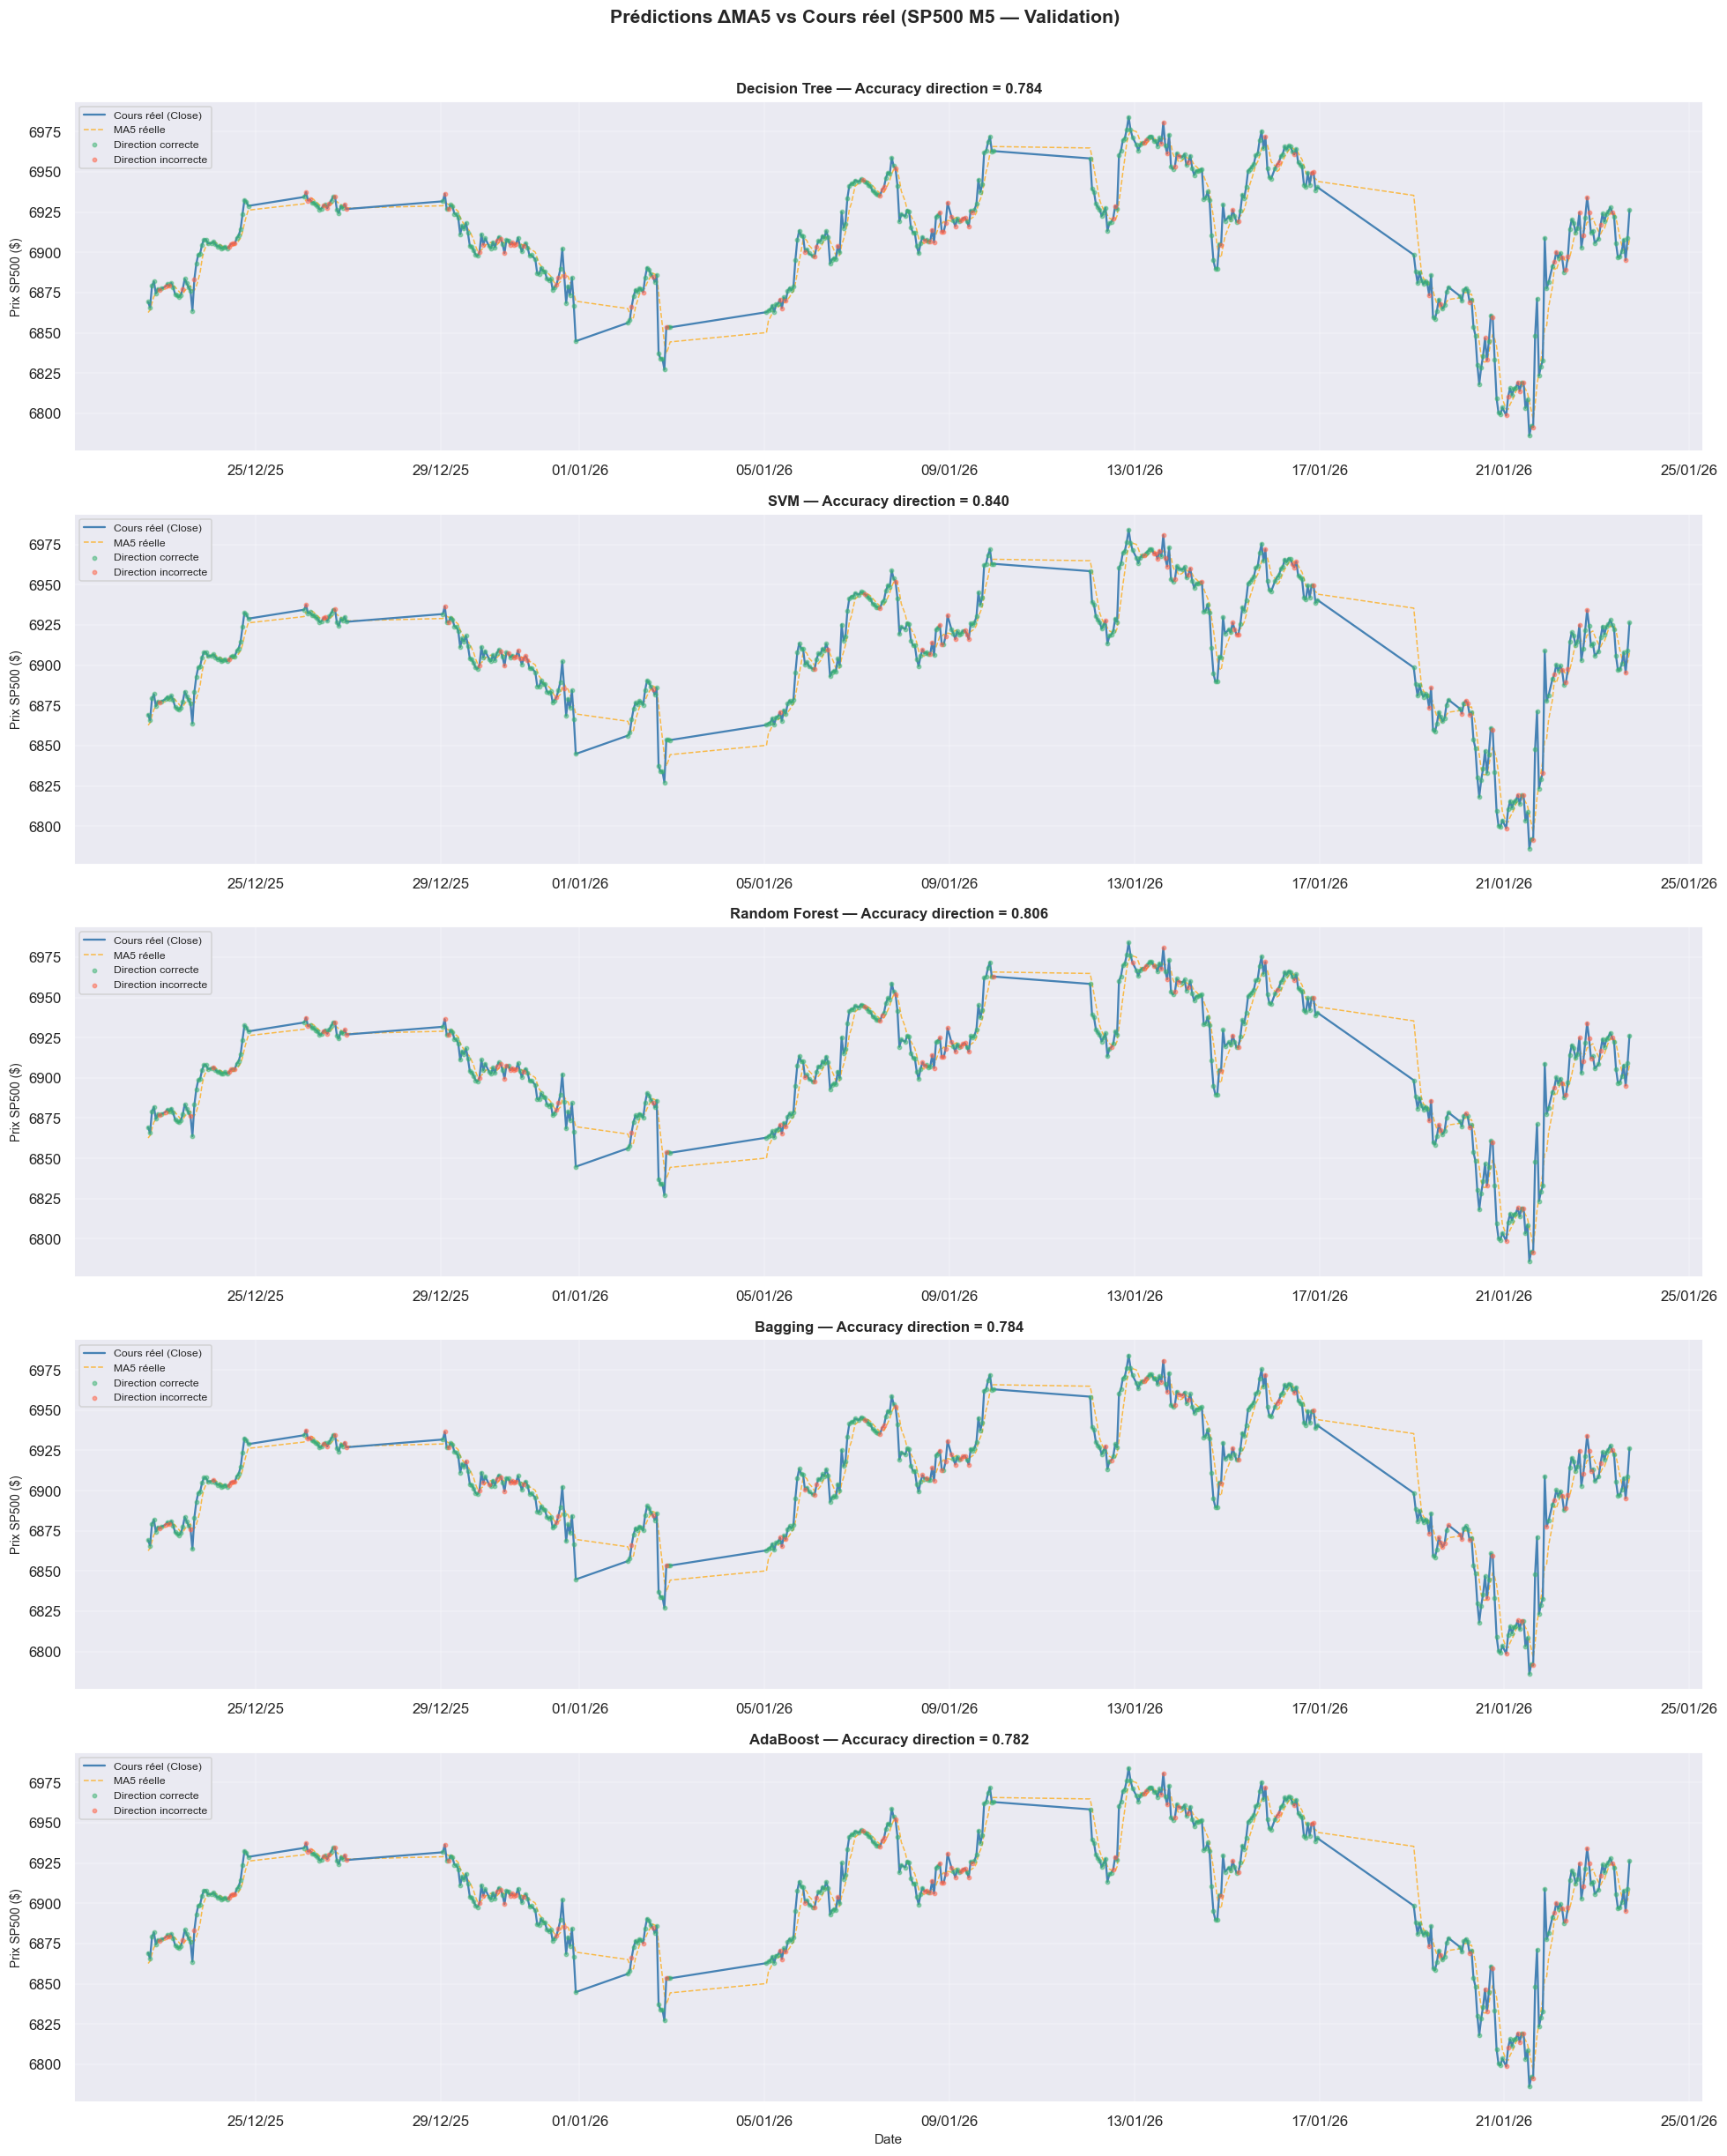


💡 Points verts = direction correctement prédite | Points rouges = erreur de direction
   Fenêtre affichée : 2025-12-22 → 2026-01-23 (500 bougies M5)


In [10]:
# ── Visualisation prédictions régression vs cours réel ────────────────────
# On prend un sous-ensemble lisible (500 bougies consécutives au milieu du val)
N_VIZ  = 500
idx_mid = len(val) // 2
val_viz = val.iloc[idx_mid : idx_mid + N_VIZ].copy()

X_viz   = scaler.transform(val_viz[FEATURE_COLS])
dates   = val_viz.index
close_viz = val_viz['close'].values
ma5_viz   = val_viz['ma5'].values

fig, axes = plt.subplots(5, 1, figsize=(18, 22))
fig.suptitle('Prédictions ΔMA5 vs Cours réel (SP500 M5 — Validation)', 
             fontsize=14, fontweight='bold', y=1.01)

for ax, (name, model) in zip(axes, reg_models.items()):
    y_pred_viz = model.predict(X_viz)
    
    # Reconstruire le prix prédit à partir du ΔMA5 prédit
    # Prix prédit(t+1) ≈ MA5(t) + ΔMA5_prédit * 5 - Close(t-4)
    # Approximation : close_prédit ≈ close + ΔMA5_prédit
    close_pred = close_viz + y_pred_viz * 5  # approximation pédagogique
    
    # Calcul accuracy sur ce sous-ensemble
    y_real_clf = np.where(val_viz['value'].values > 0, 1, -1)
    y_pred_clf = np.where(y_pred_viz > 0, 1, -1)
    acc_viz    = accuracy_score(y_real_clf, y_pred_clf)
    
    # Direction correcte (hausse/baisse)
    correct   = y_real_clf == y_pred_clf
    incorrect = ~correct
    
    # Plot cours réel
    ax.plot(dates, close_viz, color='steelblue', linewidth=1.5, 
            label='Cours réel (Close)', zorder=3)
    
    # MA5 réelle
    ax.plot(dates, ma5_viz, color='orange', linewidth=1, 
            linestyle='--', label='MA5 réelle', alpha=0.7, zorder=2)
    
    # Signaux corrects (Long prédit et hausse réelle, ou Short prédit et baisse réelle)
    ax.scatter(dates[correct], close_viz[correct], 
               color='mediumseagreen', s=8, alpha=0.5, zorder=4, label='Direction correcte')
    ax.scatter(dates[incorrect], close_viz[incorrect], 
               color='tomato', s=8, alpha=0.5, zorder=4, label='Direction incorrecte')
    
    ax.set_title(f'{name} — Accuracy direction = {acc_viz:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Prix SP500 ($)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

print('\n💡 Points verts = direction correctement prédite | Points rouges = erreur de direction')
print(f'   Fenêtre affichée : {dates[0].date()} → {dates[-1].date()} ({N_VIZ} bougies M5)')

## 7. Optimisation du Seuil de Décision sur Validation

Optimisation du seuil sur Validation...
Decision Tree      Seuil=+0.000 | Acc Val=0.764 | Long=42% Short=58%
SVM                Seuil=+0.100 | Acc Val=0.813 | Long=55% Short=45%
Random Forest      Seuil=+0.050 | Acc Val=0.782 | Long=50% Short=50%
Bagging            Seuil=+0.000 | Acc Val=0.776 | Long=48% Short=52%
AdaBoost           Seuil=-0.350 | Acc Val=0.770 | Long=45% Short=55%


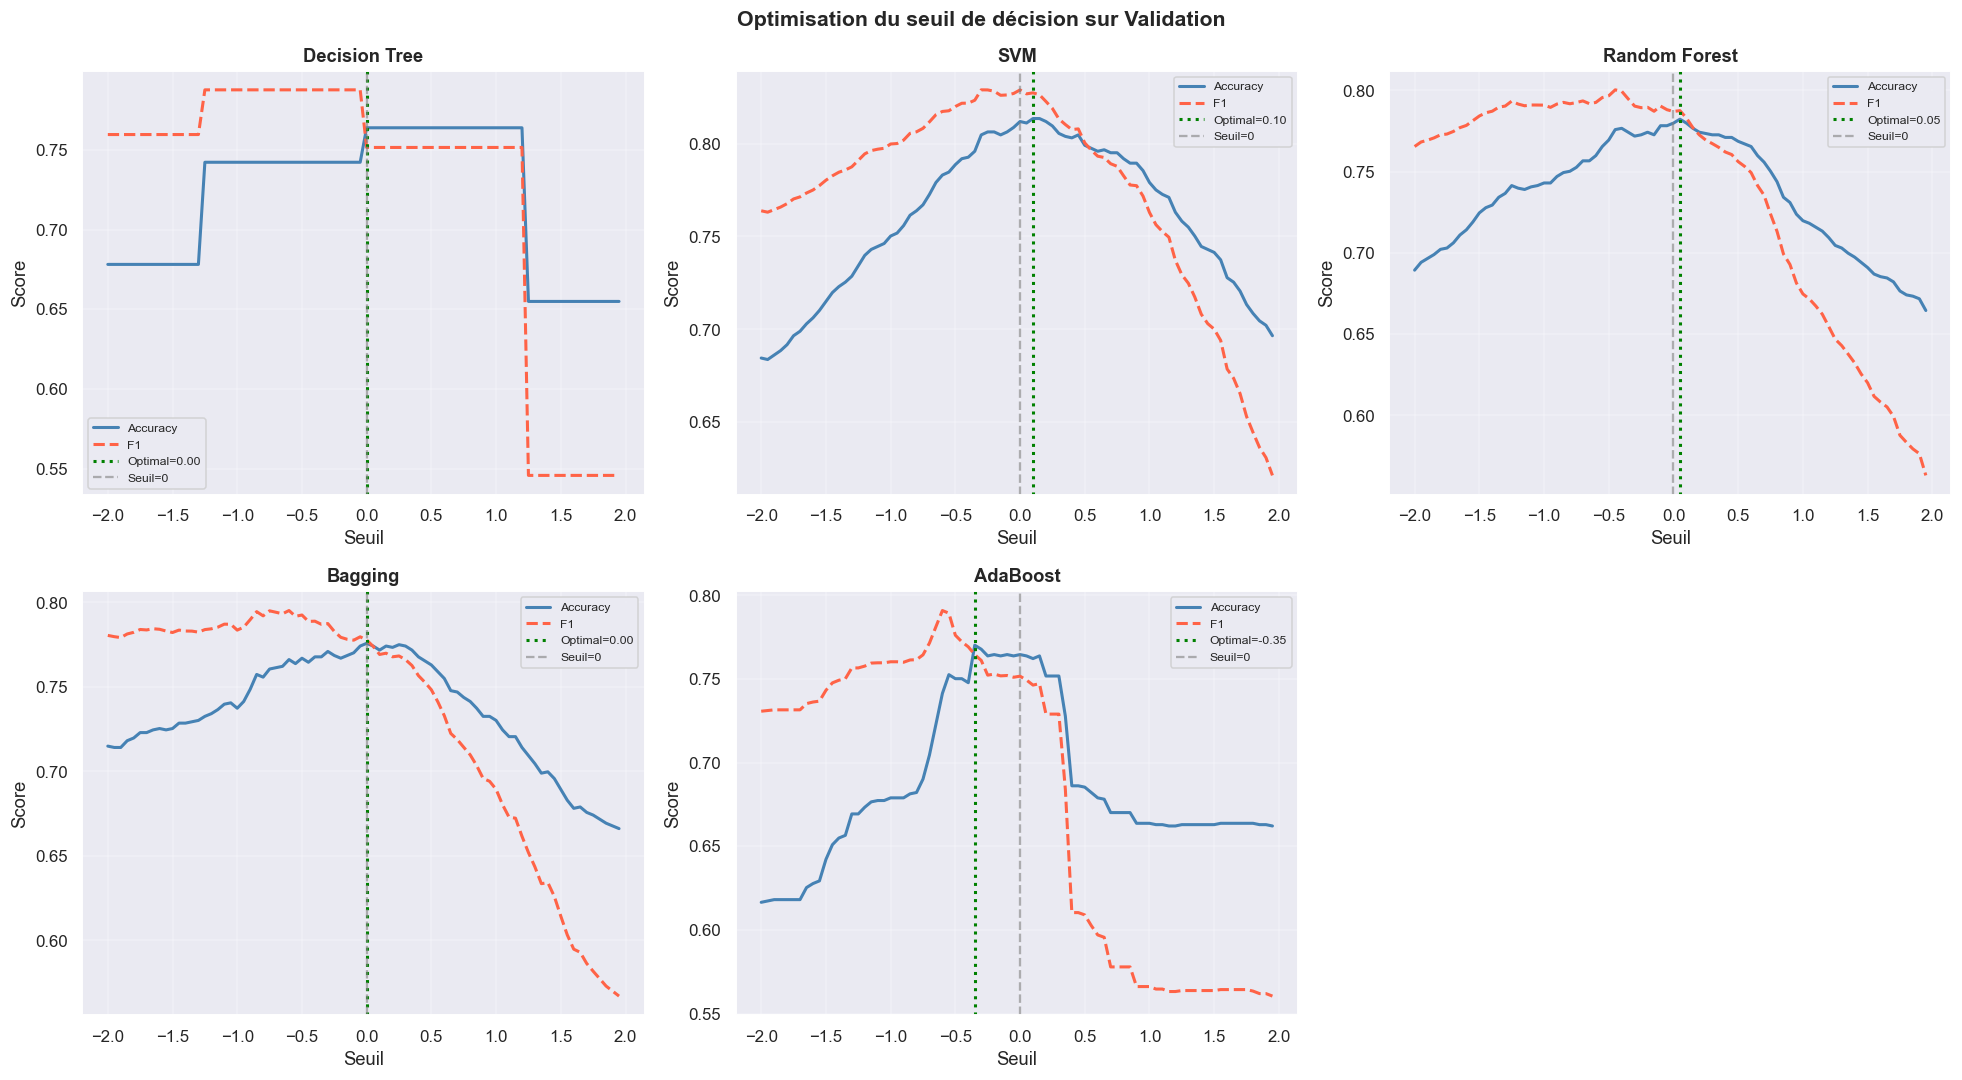

,Modèle,Seuil optimal,Acc optimale,Long (%),Short (%)
0,Decision Tree,0.00,0.764,42.4,57.6
1,SVM,0.10,0.813,55.3,44.7
2,Random Forest,0.05,0.782,49.8,50.2
3,Bagging,0.00,0.776,48.2,51.8
4,AdaBoost,-0.35,0.770,44.9,55.1


In [11]:
seuils = np.arange(-2.0, 2.0, 0.05)
best_thresholds   = {}
threshold_results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

print('Optimisation du seuil sur Validation...')
print('='*75)

for idx, (name, model) in enumerate(reg_models.items()):
    y_pred_val = model.predict(X_val)
    accs_val   = []
    f1s_val    = []

    for seuil in seuils:
        y_lbl = np.where(y_pred_val > seuil, 1, -1)
        accs_val.append(accuracy_score(y_val_clf, y_lbl))
        f1s_val.append(f1_score(y_val_clf, y_lbl, pos_label=1))

    best_idx   = np.argmax(accs_val)
    best_seuil = seuils[best_idx]
    best_acc   = accs_val[best_idx]
    best_thresholds[name] = best_seuil

    y_lbl_val = np.where(y_pred_val > best_seuil, 1, -1)
    pct_long  = np.mean(y_lbl_val == 1)  * 100
    pct_short = np.mean(y_lbl_val == -1) * 100

    threshold_results.append({
        'Modèle'       : name,
        'Seuil optimal': round(best_seuil, 3),
        'Acc optimale' : round(best_acc,   3),
        'Long (%)'     : round(pct_long,   1),
        'Short (%)'    : round(pct_short,  1)
    })
    print(f'{name:<18} Seuil={best_seuil:+.3f} | Acc Val={best_acc:.3f} | Long={pct_long:.0f}% Short={pct_short:.0f}%')

    ax = axes[idx]
    ax.plot(seuils, accs_val, color='steelblue', linewidth=2, label='Accuracy')
    ax.plot(seuils, f1s_val,  color='tomato',    linewidth=2, label='F1', linestyle='--')
    ax.axvline(best_seuil, color='green', linewidth=2,   linestyle=':',  label=f'Optimal={best_seuil:.2f}')
    ax.axvline(0,          color='gray',  linewidth=1.5, linestyle='--', label='Seuil=0', alpha=0.6)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Seuil') ; ax.set_ylabel('Score')
    ax.legend(fontsize=8)  ; ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle('Optimisation du seuil de décision sur Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

threshold_df = pd.DataFrame(threshold_results)
threshold_df

## 8. Évaluation Finale sur TEST ⚠️

**Cette cellule ne doit être exécutée qu'une seule fois.**
C'est le verdict final.

In [12]:
print('ÉVALUATION FINALE SUR TEST (verdict verrouillé)')
print('='*75)
print(f'{"Modèle":<18} {"Seuil":>7} {"R² Test":>9} {"Acc Test":>10} {"Prec":>8} {"Recall":>8} {"F1":>8}')
print('-'*75)

final_results = []
final_preds   = {}
final_values  = {}

for name, model in reg_models.items():
    seuil        = best_thresholds[name]
    y_pred_test  = model.predict(X_test)
    y_label_test = np.where(y_pred_test > seuil, 1, -1)

    final_preds[name]  = y_label_test
    final_values[name] = y_pred_test

    r2   = r2_score(y_test_reg, y_pred_test)
    acc  = accuracy_score(y_test_clf,  y_label_test)
    prec = precision_score(y_test_clf, y_label_test, pos_label=1)
    rec  = recall_score(y_test_clf,    y_label_test, pos_label=1)
    f1   = f1_score(y_test_clf,        y_label_test, pos_label=1)

    acc_val = threshold_df.loc[threshold_df['Modèle']==name, 'Acc optimale'].values[0]
    diff    = acc - acc_val
    status  = '✅' if abs(diff) < 0.05 else '⚠️ overfit'

    final_results.append({
        'Modèle'    : name,
        'Seuil'     : round(seuil, 3),
        'R² Test'   : round(r2,   3),
        'Acc Test'  : round(acc,  3),
        'Acc Val'   : round(acc_val, 3),
        'Δ Val-Test': round(diff, 3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec,  3),
        'F1'        : round(f1,   3),
        'Status'    : status
    })
    print(f'{name:<18} {seuil:>7.3f} {r2:>9.3f} {acc:>10.3f} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f} {status}')

print('='*75)
final_df  = pd.DataFrame(final_results)
best_name = final_df.loc[final_df['Acc Test'].idxmax(), 'Modèle']
best_acc  = final_df['Acc Test'].max()

print(f'\n🏆 Meilleur modèle : {best_name} — Accuracy Test = {best_acc:.3f}')
final_df

ÉVALUATION FINALE SUR TEST (verdict verrouillé)
Modèle               Seuil   R² Test   Acc Test     Prec   Recall       F1
---------------------------------------------------------------------------
Decision Tree        0.000     0.552      0.791    0.840    0.740    0.787 ✅
SVM                  0.100     0.753      0.822    0.819    0.846    0.832 ✅
Random Forest        0.050     0.677      0.806    0.823    0.800    0.812 ✅
Bagging              0.000     0.663      0.791    0.802    0.796    0.799 ✅
AdaBoost            -0.350     0.562      0.795    0.831    0.762    0.795 ✅

🏆 Meilleur modèle : SVM — Accuracy Test = 0.822


,Modèle,Seuil,R² Test,Acc Test,Acc Val,Δ Val-Test,Precision,Recall,F1,Status
0,Decision Tree,0.00,0.552,0.791,0.764,0.027,0.840,0.740,0.787,✅
1,SVM,0.10,0.753,0.822,0.813,0.009,0.819,0.846,0.832,✅
2,Random Forest,0.05,0.677,0.806,0.782,0.024,0.823,0.800,0.812,✅
3,Bagging,0.00,0.663,0.791,0.776,0.015,0.802,0.796,0.799,✅
4,AdaBoost,-0.35,0.562,0.795,0.770,0.025,0.831,0.762,0.795,✅


## 9. Matrice de Confusion — Meilleur Modèle

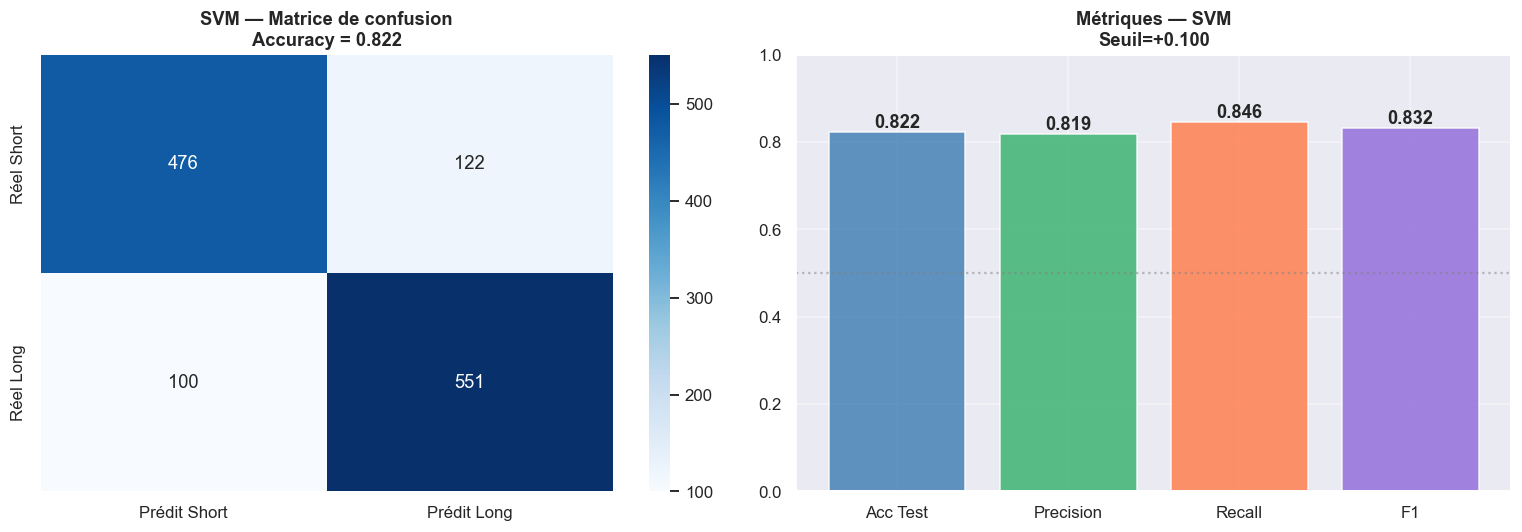


Rapport complet :
              precision    recall  f1-score   support

  Short (-1)       0.83      0.80      0.81       598
   Long (+1)       0.82      0.85      0.83       651

    accuracy                           0.82      1249
   macro avg       0.82      0.82      0.82      1249
weighted avg       0.82      0.82      0.82      1249



In [13]:
best_pred = final_preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_clf, best_pred, labels=[-1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit Short', 'Prédit Long'],
            yticklabels=['Réel Short', 'Réel Long'])
axes[0].set_title(f'{best_name} — Matrice de confusion\nAccuracy = {best_acc:.3f}', fontweight='bold')

best_row = final_df[final_df['Modèle'] == best_name].iloc[0]
metrics  = ['Acc Test', 'Precision', 'Recall', 'F1']
vals     = [best_row[m] for m in metrics]
colors   = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']
bars     = axes[1].bar(metrics, vals, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title(f'Métriques — {best_name}\nSeuil={best_thresholds[best_name]:+.3f}', fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRapport complet :')
print(classification_report(y_test_clf, best_pred, target_names=['Short (-1)', 'Long (+1)']))

## 10. Simulation de Trading Réaliste

Intégration des **coûts réels du broker** :
- Spread : 0.60 USD par trade
- SWAP overnight : -0.01703% (long) / +0.00314% (short)
- Filtre session US : 14h30–21h00 UTC uniquement

In [14]:
test_sim = test.copy()
test_sim['ml_signal']  = final_preds[best_name]

test_sim['heure']      = test_sim.index.hour
test_sim['session_us'] = (test_sim['heure'] >= 14) & (test_sim['heure'] <= 21)
test_sim['ml_signal_filtered'] = np.where(test_sim['session_us'], test_sim['ml_signal'], 0)

test_sim['ma10']       = test_sim['close'].rolling(10).mean()
test_sim['dma_signal'] = np.where(
    test_sim['ma5'] > test_sim['ma10'],  1,
    np.where(test_sim['ma5'] < test_sim['ma10'], -1, 0)
)
test_sim.dropna(inplace=True)

test_sim['log_ret']    = np.log(test_sim['close'] / test_sim['close'].shift(1))
test_sim.dropna(inplace=True)

test_sim['change_ml']  = (test_sim['ml_signal_filtered'] != test_sim['ml_signal_filtered'].shift(1)).astype(int)
test_sim['change_dma'] = (test_sim['dma_signal']         != test_sim['dma_signal'].shift(1)).astype(int)

nb_trades_ml  = test_sim['change_ml'].sum()
nb_trades_dma = test_sim['change_dma'].sum()
print(f'Nombre de trades ML  : {nb_trades_ml:,}  | Coût spread : {nb_trades_ml * SPREAD_USD:,.2f} USD')
print(f'Nombre de trades DMA : {nb_trades_dma:,} | Coût spread : {nb_trades_dma * SPREAD_USD:,.2f} USD')

cout_spread_par_trade = SPREAD_USD / CAPITAL_INIT
test_sim['ret_ml_brut']  = test_sim['ml_signal_filtered'].shift(1) * test_sim['log_ret']
test_sim['ret_ml_net']   = test_sim['ret_ml_brut']  - (test_sim['change_ml']  * cout_spread_par_trade)
test_sim['ret_dma_brut'] = test_sim['dma_signal'].shift(1) * test_sim['log_ret']
test_sim['ret_dma_net']  = test_sim['ret_dma_brut'] - (test_sim['change_dma'] * cout_spread_par_trade)
test_sim['ret_bh']       = test_sim['log_ret']
test_sim.dropna(inplace=True)

# SWAP vectorisé
overnight_mask = test_sim.index.hour == 23
triple_mask    = test_sim.index.dayofweek == 4
mult           = np.where(triple_mask, 3, 1)
swap_long  = np.where(test_sim['ml_signal_filtered'] == 1,  CAPITAL_INIT * abs(SWAP_LONG_PCT)  * mult, 0)
swap_short = np.where(test_sim['ml_signal_filtered'] == -1, CAPITAL_INIT * abs(SWAP_SHORT_PCT) * mult, 0)
swap_cost_ml = (swap_long + swap_short)[overnight_mask].sum()
print(f'Coût SWAP overnight ML : {swap_cost_ml:,.2f} USD')

test_sim['equity_ml_net']  = CAPITAL_INIT * np.exp(test_sim['ret_ml_net'].cumsum())
test_sim['equity_dma_net'] = CAPITAL_INIT * np.exp(test_sim['ret_dma_net'].cumsum())
test_sim['equity_bh']      = CAPITAL_INIT * np.exp(test_sim['ret_bh'].cumsum())
test_sim['equity_ml_net'] -= swap_cost_ml / len(test_sim)

print('\n✅ Simulation prête')

Nombre de trades ML  : 185  | Coût spread : 111.00 USD
Nombre de trades DMA : 129 | Coût spread : 77.40 USD
Coût SWAP overnight ML : 0.00 USD

✅ Simulation prête


## 11. Résultats de Trading

  RÉSULTATS TRADING (coûts broker intégrés)
                         ML Strategy (SVM)  Double MA Strategy  Buy & Hold
Capital final ($)               100725.000          104040.000  103038.000
Rendement annualisé (%)              0.890               4.960       3.720
Max Drawdown (%)                    -8.010              -9.480      -9.660
Sharpe Ratio                         0.133               0.525       0.397


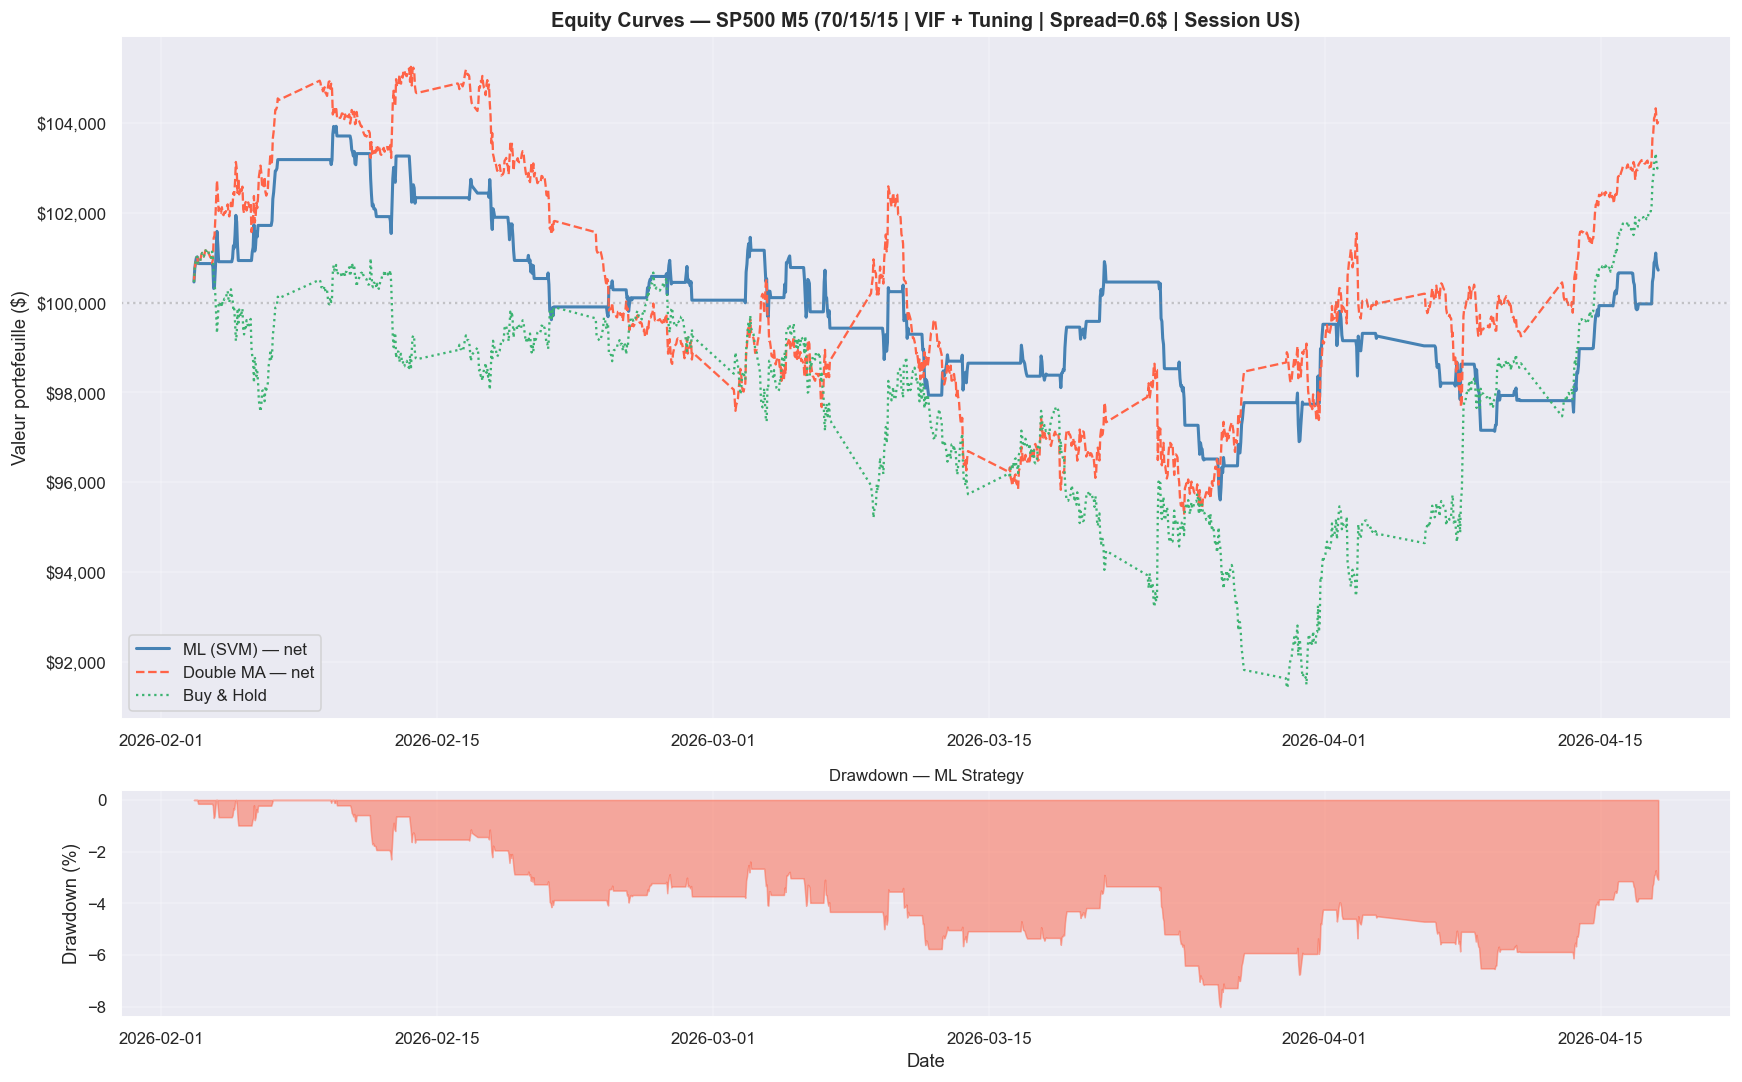

In [15]:
def compute_metrics(ret_series, equity_series):
    total_ret  = np.exp(ret_series.sum()) - 1
    n          = len(ret_series)
    annualized = (1 + total_ret) ** (BOUGIES_PAR_AN / n) - 1
    peak       = equity_series.cummax()
    dd         = (equity_series - peak) / peak
    max_dd     = dd.min()
    sharpe     = ret_series.mean() / ret_series.std() * np.sqrt(BOUGIES_PAR_AN) if ret_series.std() > 0 else 0
    return {
        'Capital final ($)'      : round(equity_series.iloc[-1], 0),
        'Rendement annualisé (%)': round(annualized * 100, 2),
        'Max Drawdown (%)'       : round(max_dd * 100, 2),
        'Sharpe Ratio'           : round(sharpe, 3)
    }

m_ml  = compute_metrics(test_sim['ret_ml_net'],  test_sim['equity_ml_net'])
m_dma = compute_metrics(test_sim['ret_dma_net'], test_sim['equity_dma_net'])
m_bh  = compute_metrics(test_sim['ret_bh'],      test_sim['equity_bh'])

results_table = pd.DataFrame({
    f'ML Strategy ({best_name})': m_ml,
    'Double MA Strategy'        : m_dma,
    'Buy & Hold'                : m_bh
})

print('='*65)
print('  RÉSULTATS TRADING (coûts broker intégrés)')
print('='*65)
print(results_table.to_string())
print('='*65)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(test_sim.index, test_sim['equity_ml_net'],  label=f'ML ({best_name}) — net',  color='steelblue',      linewidth=2)
axes[0].plot(test_sim.index, test_sim['equity_dma_net'], label='Double MA — net',           color='tomato',         linewidth=1.5, linestyle='--')
axes[0].plot(test_sim.index, test_sim['equity_bh'],      label='Buy & Hold',                color='mediumseagreen', linewidth=1.5, linestyle=':')
axes[0].axhline(CAPITAL_INIT, color='gray', linestyle=':', alpha=0.4)
axes[0].set_title(f'Equity Curves — SP500 M5 (70/15/15 | VIF + Tuning | Spread={SPREAD_USD}$ | Session US)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valeur portefeuille ($)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

peak  = test_sim['equity_ml_net'].cummax()
dd_ml = (test_sim['equity_ml_net'] - peak) / peak * 100
axes[1].fill_between(test_sim.index, dd_ml, 0, color='tomato', alpha=0.5)
axes[1].set_title('Drawdown — ML Strategy', fontsize=11)
axes[1].set_ylabel('Drawdown (%)') ; axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Résumé Final

In [16]:
print('='*65)
print('  RÉSUMÉ FINAL — Wang & Yan SP500 H1 (depuis M5)')
print('='*65)
print(f'  Données source     : M5 rééchantillonné en H1')
print(f'  Bougies H1         : {len(df):,}')
print(f'  Split              : 70% Train | 15% Val | 15% Test')
print(f'  Features           : {len(FEATURE_COLS)} variables')
print(f'  Tuning             : RandomizedSearch {N_ITER_SEARCH} iter × {N_CV_FOLDS} folds TS')
print(f'  Meilleur modèle    : {best_name}')
print(f'  Seuil optimal      : {best_thresholds[best_name]:+.3f}')
print(f'  Accuracy Test      : {best_acc:.3f}')
print(f'  Capital final ML   : ${m_ml["Capital final ($)"]:,.0f}')
print(f'  Rendement ML       : {m_ml["Rendement annualisé (%)"]:.2f}% annualisé')
print(f'  Sharpe ML          : {m_ml["Sharpe Ratio"]:.3f}')
print(f'  Max Drawdown ML    : {m_ml["Max Drawdown (%)"]:.2f}%')
print('='*65)
print('\nComparaison Val vs Test (contrôle overfitting) :')
for _, row in final_df.iterrows():
    print(f'  {row["Modèle"]:<18} Val={row["Acc Val"]:.3f} | Test={row["Acc Test"]:.3f} | Δ={row["Δ Val-Test"]:+.3f} {row["Status"]}')
print('='*65)

  RÉSUMÉ FINAL — Wang & Yan SP500 H1 (depuis M5)
  Données source     : M5 rééchantillonné en H1
  Bougies H1         : 8,346
  Split              : 70% Train | 15% Val | 15% Test
  Features           : 26 variables
  Tuning             : RandomizedSearch 30 iter × 5 folds TS
  Meilleur modèle    : SVM
  Seuil optimal      : +0.100
  Accuracy Test      : 0.822
  Capital final ML   : $100,725
  Rendement ML       : 0.89% annualisé
  Sharpe ML          : 0.133
  Max Drawdown ML    : -8.01%

Comparaison Val vs Test (contrôle overfitting) :
  Decision Tree      Val=0.764 | Test=0.791 | Δ=+0.027 ✅
  SVM                Val=0.813 | Test=0.822 | Δ=+0.009 ✅
  Random Forest      Val=0.782 | Test=0.806 | Δ=+0.024 ✅
  Bagging            Val=0.776 | Test=0.791 | Δ=+0.015 ✅
  AdaBoost           Val=0.770 | Test=0.795 | Δ=+0.025 ✅


  RÉSULTATS TRADING (coûts broker intégrés)
                         ML Strategy (SVM)  Double MA Strategy  Buy & Hold
Capital final ($)               100725.000          104040.000  103038.000
Rendement annualisé (%)              0.890               4.960       3.720
Max Drawdown (%)                    -8.010              -9.480      -9.660
Sharpe Ratio                         0.133               0.525       0.397


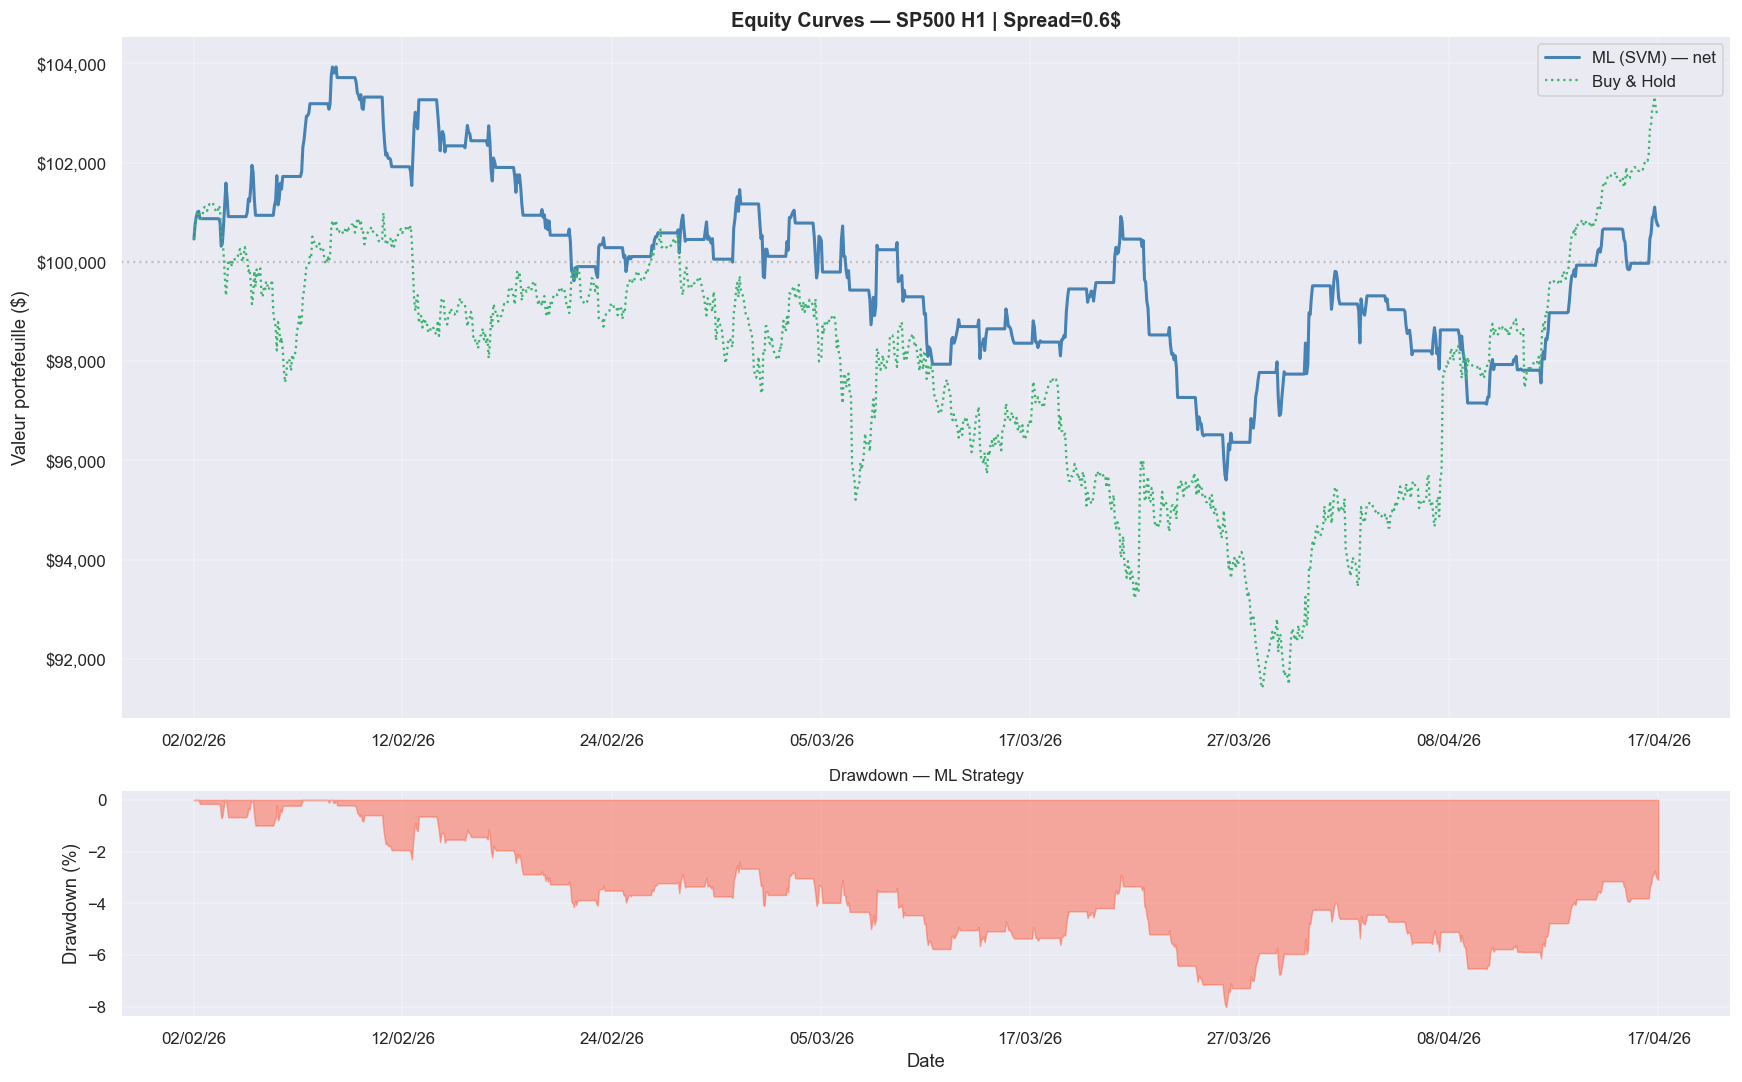

In [18]:
def compute_metrics(ret_series, equity_series):
    total_ret  = np.exp(ret_series.sum()) - 1
    n          = len(ret_series)
    annualized = (1 + total_ret) ** (BOUGIES_PAR_AN / n) - 1
    peak       = equity_series.cummax()
    dd         = (equity_series - peak) / peak
    max_dd     = dd.min()
    sharpe     = ret_series.mean() / ret_series.std() * np.sqrt(BOUGIES_PAR_AN) if ret_series.std() > 0 else 0
    return {
        'Capital final ($)'      : round(equity_series.iloc[-1], 0),
        'Rendement annualisé (%)': round(annualized * 100, 2),
        'Max Drawdown (%)'       : round(max_dd * 100, 2),
        'Sharpe Ratio'           : round(sharpe, 3)
    }

m_ml  = compute_metrics(test_sim['ret_ml_net'],  test_sim['equity_ml_net'])
m_dma = compute_metrics(test_sim['ret_dma_net'], test_sim['equity_dma_net'])
m_bh  = compute_metrics(test_sim['ret_bh'],      test_sim['equity_bh'])

results_table = pd.DataFrame({
    f'ML Strategy ({best_name})': m_ml,
    'Double MA Strategy'        : m_dma,
    'Buy & Hold'                : m_bh
})

print('='*65)
print('  RÉSULTATS TRADING (coûts broker intégrés)')
print('='*65)
print(results_table.to_string())
print('='*65)

# ── Lissage : on réindexe sur un index entier pour supprimer les gaps weekend
# On garde les vraies dates en label mais on trace sur position entière
equity_ml = test_sim['equity_ml_net'].reset_index(drop=True)
equity_bh = test_sim['equity_bh'].reset_index(drop=True)
dd_ml_s   = (equity_ml - equity_ml.cummax()) / equity_ml.cummax() * 100

# Labels de dates espacés proprement
dates      = test_sim.index
n_ticks    = 8
tick_pos   = np.linspace(0, len(dates)-1, n_ticks, dtype=int)
tick_labels= [dates[i].strftime('%d/%m/%y') for i in tick_pos]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# ── Panel 1 : equity curves ───────────────────────────────────────────────
axes[0].plot(equity_ml.index, equity_ml,
             label=f'ML ({best_name}) — net', color='steelblue', linewidth=2)
axes[0].plot(equity_bh.index, equity_bh,
             label='Buy & Hold', color='mediumseagreen', linewidth=1.5, linestyle=':')
axes[0].axhline(CAPITAL_INIT, color='gray', linestyle=':', alpha=0.4)
axes[0].set_title(f'Equity Curves — SP500 H1 | Spread={SPREAD_USD}$',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valeur portefeuille ($)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].set_xticks(tick_pos)
axes[0].set_xticklabels(tick_labels)
axes[0].grid(True, alpha=0.3)

# ── Panel 2 : drawdown ────────────────────────────────────────────────────
axes[1].fill_between(dd_ml_s.index, dd_ml_s, 0, color='tomato', alpha=0.5)
axes[1].set_title('Drawdown — ML Strategy', fontsize=11)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].set_xticks(tick_pos)
axes[1].set_xticklabels(tick_labels)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ── Stats descriptives sur les features du modèle ─────────────────────────
print('Stats descriptives — 26 features utilisées par le modèle')
print('='*65)

stats = feat[FEATURE_COLS].describe().T
stats = stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats = stats.round(4)

print(stats.to_string())

Stats descriptives — 26 features utilisées par le modèle
                    mean          std          min          25%          50%          75%         max
close_1        6318.9201     472.6248    4828.5300    5965.9600    6368.0900    6764.7000   7147.2600
close_incr        0.1459      13.8717    -204.4500      -4.2500       0.2500       4.8600    337.4300
ma5            6318.7745     472.3964    4870.2280    5966.2640    6370.1060    6765.0480   7133.8840
ma5_1          6318.6287     472.3323    4870.2280    5966.0420    6369.8900    6765.0040   7133.8840
ma5_incr          0.1458       6.3140     -56.7160      -2.0580       0.3460       2.6440    100.6200
ma20           6317.7308     471.4116    4933.6275    5964.4990    6372.2525    6763.7890   7081.3865
ma20_1         6317.5943     471.3550    4933.6275    5964.4770    6372.1845    6763.7605   7077.4860
ma20_incr         0.1365       3.1639     -26.1175      -1.1795       0.2375       1.6815     29.0175
ma5_20            1.0437 

In [20]:
# ── Stats descriptives — SP500 H1 ────────────────────────────────────────
print('Stats descriptives — SP500 H1 (rééchantillonné depuis M5)')
print('='*65)

# Stats sur les prix OHLCV
print('\n── Prix & Volume ──')
stats_prix = df[['open', 'high', 'low', 'close', 'volume']].describe().T
stats_prix = stats_prix[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)
print(stats_prix.to_string())

# Log returns
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

print('\n── Log Returns ──')
stats_ret = df[['log_ret']].describe().T
stats_ret = stats_ret[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(6)
print(stats_ret.to_string())

# Stats supplémentaires
r = df['log_ret'].dropna()
from scipy import stats as scipy_stats
print(f'\n── Propriétés statistiques ──')
print(f'   Skewness        : {r.skew():.4f}')
print(f'   Kurtosis exc.   : {r.kurtosis():.4f}')
print(f'   Vol. annualisée : {r.std() * np.sqrt(252*6) * 100:.2f}%')

# Test Jarque-Bera
jb, jb_p = scipy_stats.jarque_bera(r)
print(f'\n── Test de Jarque-Bera ──')
print(f'   Statistique : {jb:.2f}')
print(f'   p-value     : {jb_p:.4f}')
print(f'   Normalité   : {"❌ Rejetée" if jb_p < 0.05 else "✅ Non rejetée"}')


Stats descriptives — SP500 H1 (rééchantillonné depuis M5)

── Prix & Volume ──
             mean        std      min        25%       50%        75%       max
open    6318.1189   472.4990  4828.65  5965.0300  6365.095  6763.5150   7147.51
high    6325.7947   471.0048  4857.15  5971.5150  6372.630  6772.2225   7151.76
low     6310.1195   474.0429  4804.28  5956.8900  6360.030  6755.6700   7133.26
close   6318.2669   472.5306  4828.53  5965.2075  6365.435  6764.0250   7147.26
volume  2738.0223  2401.5868     3.00   916.2500  1927.000  3850.7500  16216.00

── Log Returns ──
             mean      std       min       25%       50%       75%       max
log_ret  0.000021  0.00235 -0.041213 -0.000678  0.000041  0.000761  0.064933

── Propriétés statistiques ──
   Skewness        : 1.8931
   Kurtosis exc.   : 94.9075
   Vol. annualisée : 9.14%

── Test de Jarque-Bera ──
   Statistique : 3133142.62
   p-value     : 0.0000
   Normalité   : ❌ Rejetée


Descriptive Statistics — SP500 H1 (resampled from M5)

── Price & Volume ──
             mean        std      min        25%       50%        75%       max
open    6318.1189   472.4990  4828.65  5965.0300  6365.095  6763.5150   7147.51
high    6325.7947   471.0048  4857.15  5971.5150  6372.630  6772.2225   7151.76
low     6310.1195   474.0429  4804.28  5956.8900  6360.030  6755.6700   7133.26
close   6318.2669   472.5306  4828.53  5965.2075  6365.435  6764.0250   7147.26
volume  2738.0223  2401.5868     3.00   916.2500  1927.000  3850.7500  16216.00

── Log Returns ──
   Mean            : 0.000021
   Std             : 0.002350
   Min             : -0.041213
   Max             : 0.064933
   Skewness        : 1.8931
   Excess Kurtosis : 94.9075
   Ann. Volatility : 9.14%

── Jarque-Bera Test ──
   Statistic : 3133142.62
   p-value   : 0.0000
   Normality : ❌ Rejected


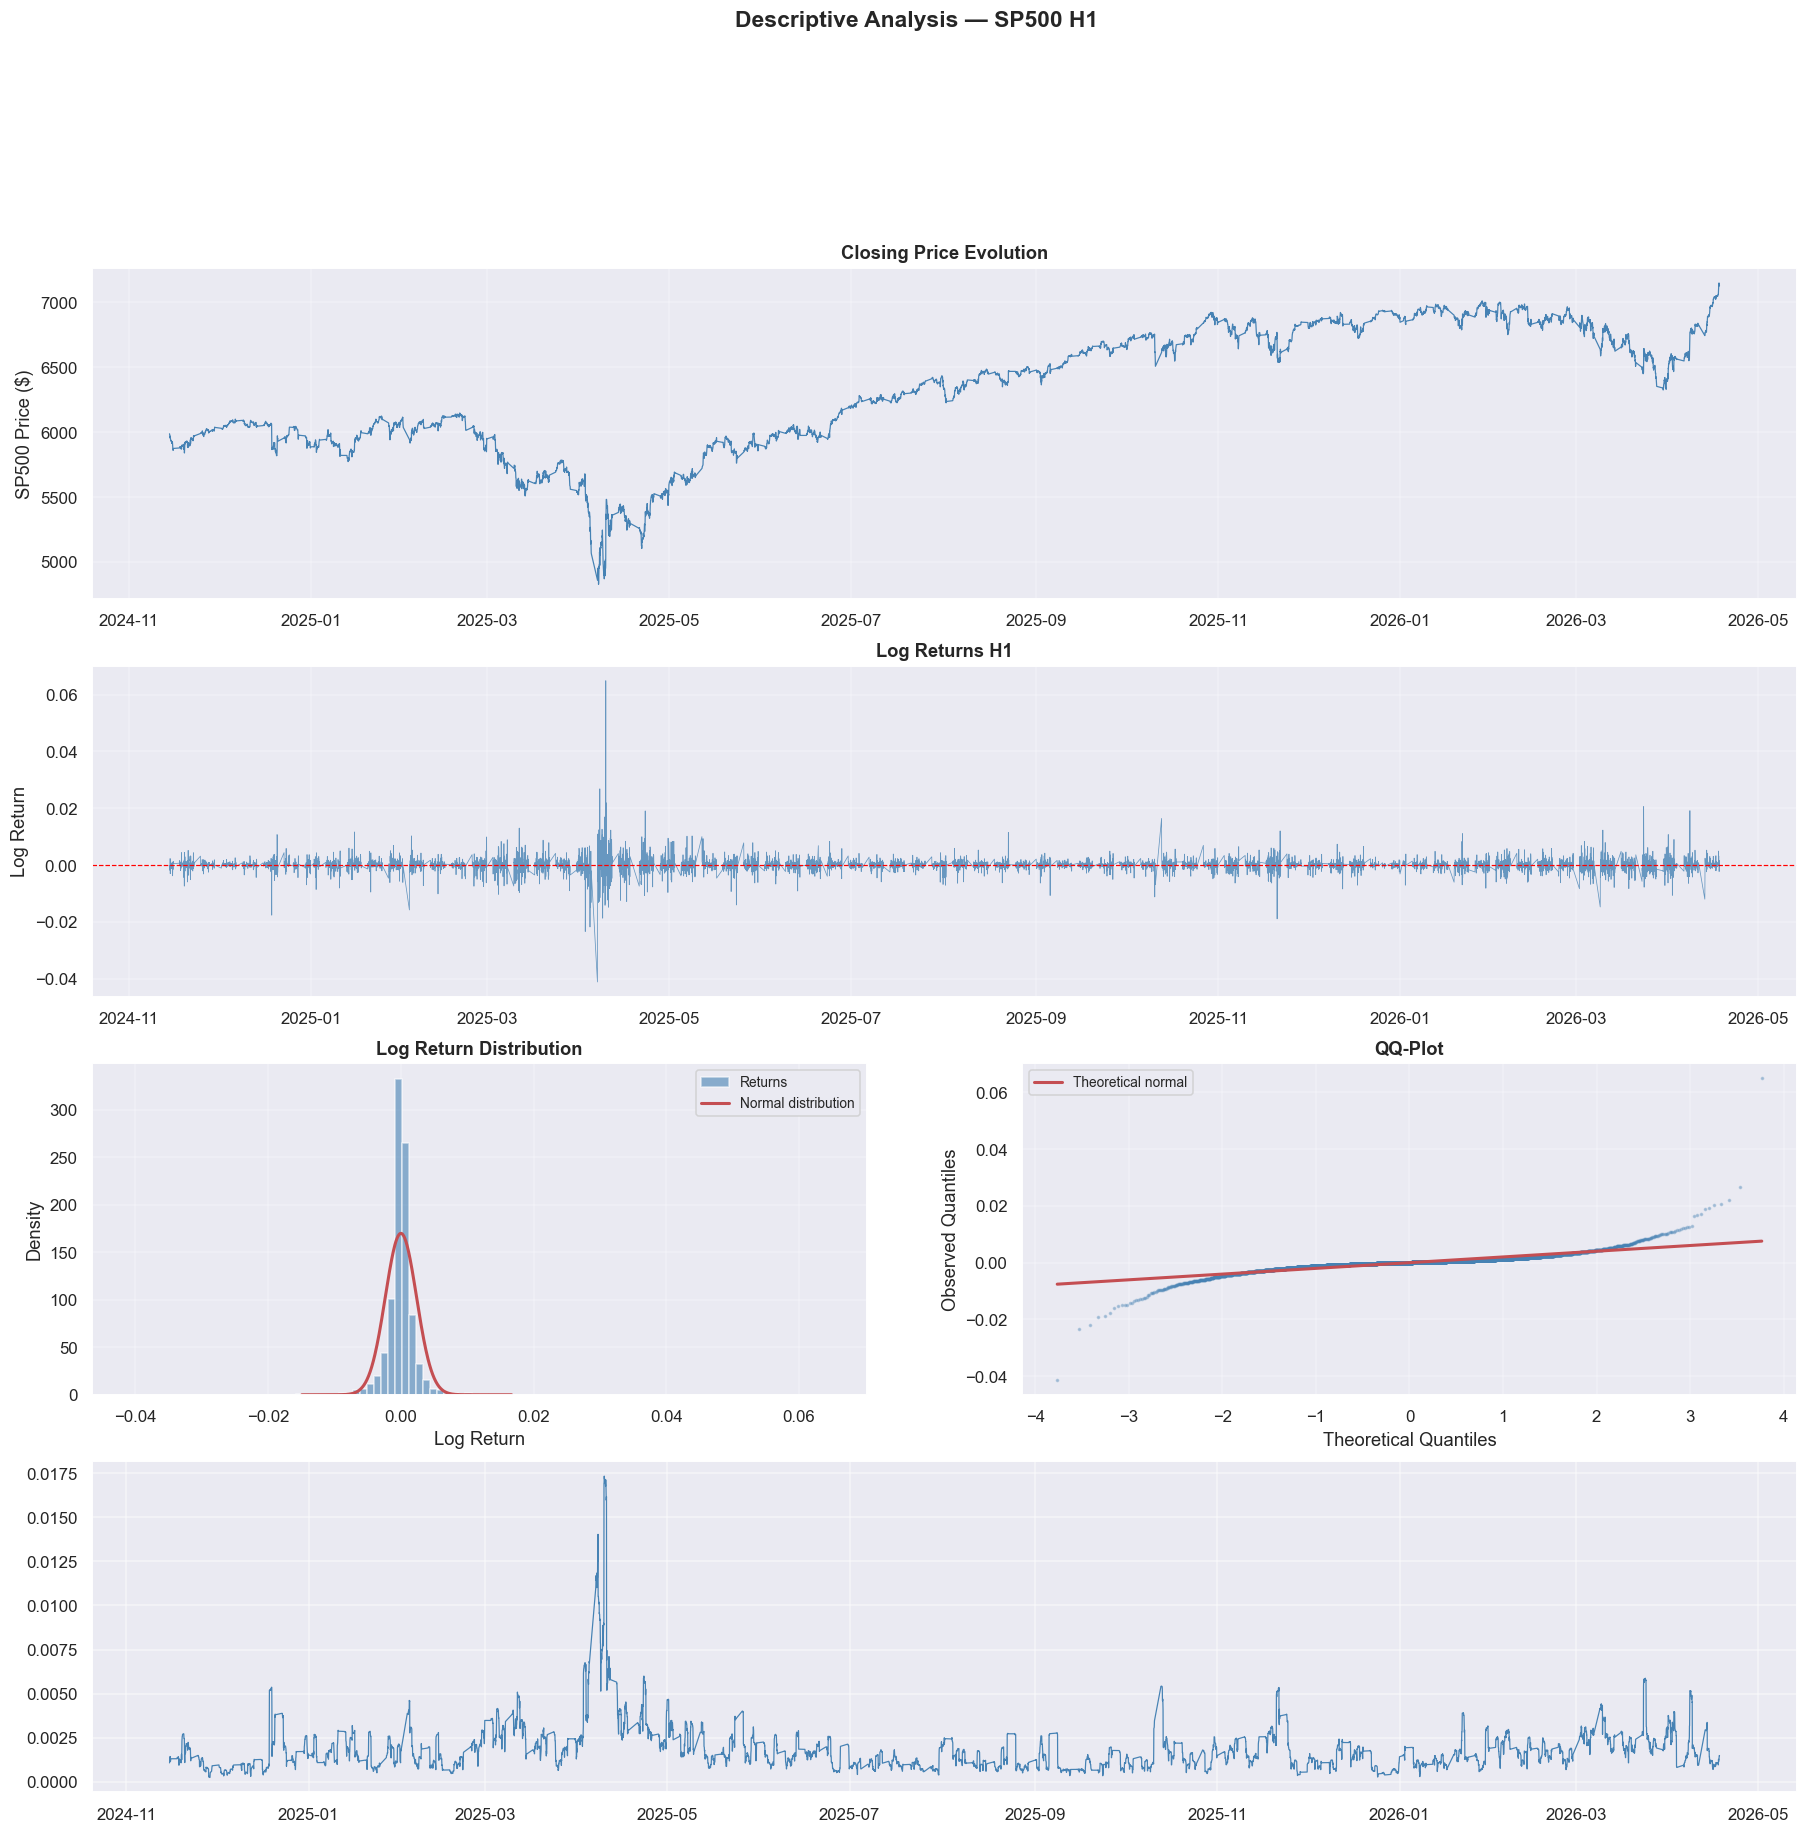

In [23]:
# ── Stats descriptives — SP500 H1 ────────────────────────────────────────
from scipy import stats as scipy_stats

df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
r             = df['log_ret'].dropna()
dates         = df.index[1:]  # aligné sur r

# ── Tableau des stats ─────────────────────────────────────────────────────
print('Descriptive Statistics — SP500 H1 (resampled from M5)')
print('='*65)
print('\n── Price & Volume ──')
stats_prix = df[['open', 'high', 'low', 'close', 'volume']].describe().T
stats_prix = stats_prix[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)
print(stats_prix.to_string())

print('\n── Log Returns ──')
print(f'   Mean            : {r.mean():.6f}')
print(f'   Std             : {r.std():.6f}')
print(f'   Min             : {r.min():.6f}')
print(f'   Max             : {r.max():.6f}')
print(f'   Skewness        : {r.skew():.4f}')
print(f'   Excess Kurtosis : {r.kurtosis():.4f}')
print(f'   Ann. Volatility : {r.std() * np.sqrt(252*6) * 100:.2f}%')

jb, jb_p = scipy_stats.jarque_bera(r)
print(f'\n── Jarque-Bera Test ──')
print(f'   Statistic : {jb:.2f}')
print(f'   p-value   : {jb_p:.4f}')
print(f'   Normality : {"❌ Rejected" if jb_p < 0.05 else "✅ Not rejected"}')

# ── Graphiques ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Descriptive Analysis — SP500 H1', fontsize=15,
             fontweight='bold', y=1.01)

# ── 1. Closing price ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(4, 2, (1, 2))
ax1.plot(df.index, df['close'], color='steelblue', linewidth=0.8)
ax1.set_title('Closing Price Evolution', fontweight='bold')
ax1.set_ylabel('SP500 Price ($)')
ax1.grid(True, alpha=0.3)

# ── 2. Log returns ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 2, (3, 4))
ax2.plot(dates, r, color='steelblue', linewidth=0.5, alpha=0.8)
ax2.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax2.set_title('Log Returns H1', fontweight='bold')
ax2.set_ylabel('Log Return')
ax2.grid(True, alpha=0.3)

# ── 3. Return distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 2, 5)
ax3.hist(r, bins=100, density=True, alpha=0.6,
         color='steelblue', label='Returns', edgecolor='white')
x = np.linspace(r.quantile(0.001), r.quantile(0.999), 400)
ax3.plot(x, scipy_stats.norm.pdf(x, r.mean(), r.std()),
         'r-', linewidth=2, label='Normal distribution')
ax3.set_title('Log Return Distribution', fontweight='bold')
ax3.set_xlabel('Log Return')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── 4. QQ-Plot ────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 2, 6)
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(r, dist='norm')
ax4.scatter(osm, osr, s=2, alpha=0.3, color='steelblue')
ax4.plot(osm, slope * np.array(osm) + intercept, 'r-',
         linewidth=2, label='Theoretical normal')
ax4.set_title('QQ-Plot', fontweight='bold')
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Observed Quantiles')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── 5. Rolling volatility ─────────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, (7, 8))
vol_roll = r.rolling(20).std()
ax5.plot(dates, vol_roll, color='steelblue', linewidth=0.8)

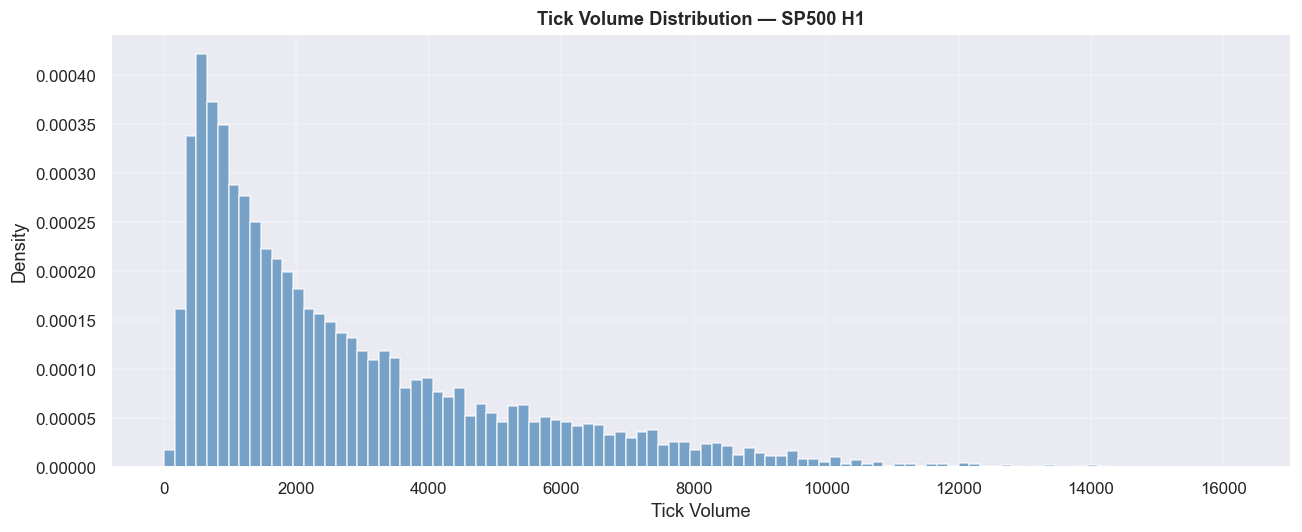

In [25]:
# ── Volume distribution — SP500 H1 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['volume'], bins=100, color='steelblue',
        alpha=0.7, edgecolor='white', density=True)
ax.set_title('Tick Volume Distribution — SP500 H1', fontweight='bold')
ax.set_xlabel('Tick Volume')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
print(df['log_ret'].describe())


count    8345.000000
mean        0.000021
std         0.002350
min        -0.041213
25%        -0.000678
50%         0.000041
75%         0.000761
max         0.064933
Name: log_ret, dtype: float64


Rang  Feature             Coefficient     |Coef|
------------------------------------------------


IndexError: invalid index to scalar variable.

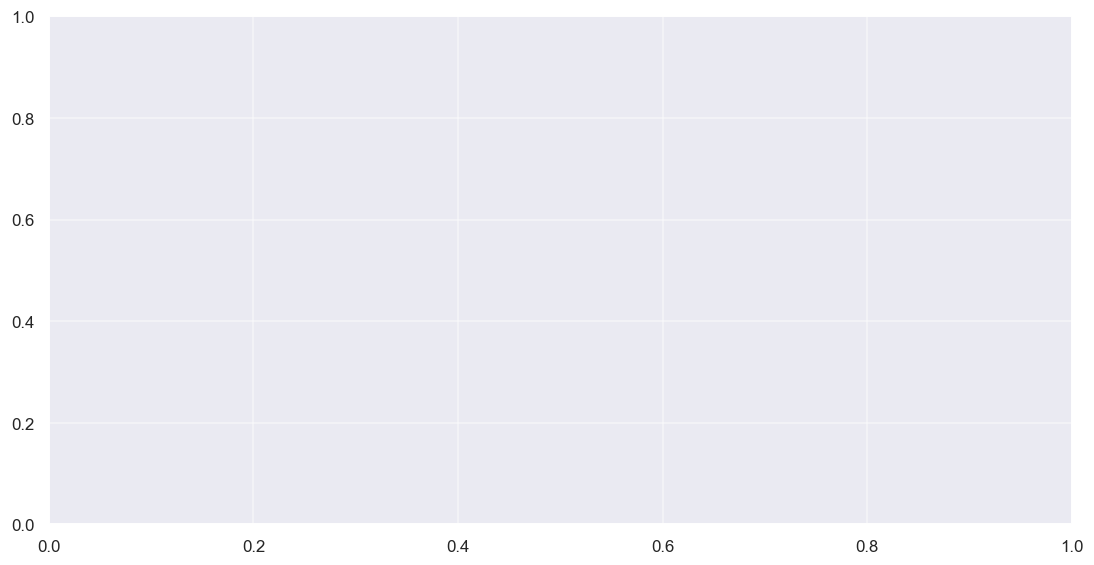

In [28]:
## 8b. Feature Importance — LinearSVR (coefficients natifs)

fig, ax = plt.subplots(figsize=(12, 6))

coefs        = reg_models['SVM'].coef_[0]
feature_names = np.array(FEATURE_COLS)
indices      = np.argsort(np.abs(coefs))[::-1]

print(f"{'Rang':<5} {'Feature':<18} {'Coefficient':>12} {'|Coef|':>10}")
print("-"*48)
for rank, i in enumerate(indices, 1):
    print(f"{rank:<5} {feature_names[i]:<18} {coefs[i]:>12.4f} {abs(coefs[i]):>10.4f}")

top_n   = 15
top_idx = indices[:top_n]
colors  = ['steelblue' if coefs[i] > 0 else 'coral' for i in top_idx[::-1]]

ax.barh(range(top_n), coefs[top_idx][::-1], color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(feature_names[top_idx][::-1], fontsize=11)
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Coefficient (standardisé)', fontsize=11)
ax.set_title('Feature Importance — LinearSVR\n(coefficients natifs, bleu = hausse, rouge = baisse)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Rank  Feature             Coefficient     |Coef|
------------------------------------------------
1     close                   25.4675    25.4675
2     close_1                 25.4471    25.4471
3     ma5_1                  -17.5907    17.5907
4     ma5                    -17.5683    17.5683
5     ma20_1                 -17.0384    17.0384
6     ma20                   -17.0308    17.0308
7     open                     9.3934     9.3934
8     ma5_20                  -8.6210     8.6210
9     low                      8.1202     8.1202
10    macd_hist                4.7459     4.7459
11    macd                     2.6147     2.6147
12    macd_signal              1.1214     1.1214
13    ma5_incr                 1.1134     1.1134
14    mom                      1.1134     1.1134
15    high                     1.0821     1.0821
16    close_incr               0.8009     0.8009
17    roc_20                  -0.7282     0.7282
18    roc_5                   -0.5005     0.5005
19    ma20_incr     

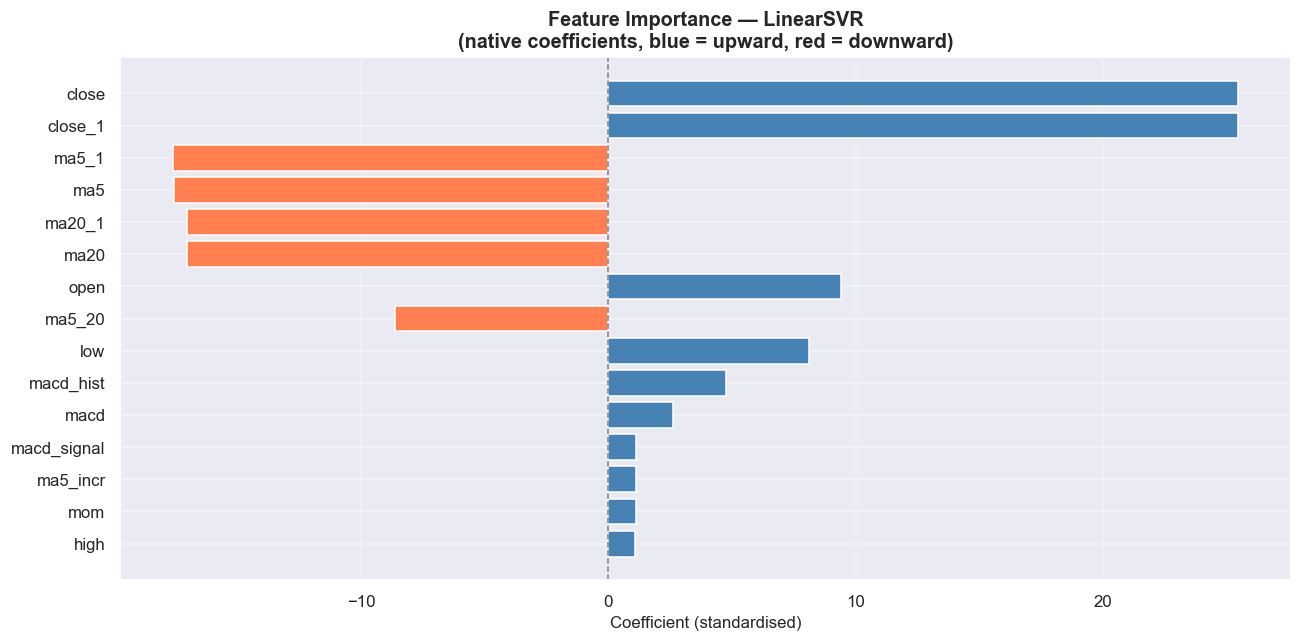

In [32]:
## 8b. Feature Importance — LinearSVR (native coefficients)

fig, ax = plt.subplots(figsize=(12, 6))

coefs         = reg_models['SVM'].coef_.flatten()
feature_names = np.array(FEATURE_COLS)
indices       = np.argsort(np.abs(coefs))[::-1]

print(f"{'Rank':<5} {'Feature':<18} {'Coefficient':>12} {'|Coef|':>10}")
print("-"*48)
for rank, i in enumerate(indices, 1):
    print(f"{rank:<5} {feature_names[i]:<18} {coefs[i]:>12.4f} {abs(coefs[i]):>10.4f}")

top_n   = 15
top_idx = indices[:top_n]
colors  = ['steelblue' if coefs[i] > 0 else 'coral' for i in top_idx[::-1]]

ax.barh(range(top_n), coefs[top_idx][::-1], color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(feature_names[top_idx][::-1], fontsize=11)
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Coefficient (standardised)', fontsize=11)
ax.set_title('Feature Importance — LinearSVR\n(native coefficients, blue = upward, red = downward)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [30]:
## 8c. Modèle SVM réduit — Top features uniquement

from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

# ── Features sélectionnées d'après les coefficients ───────────────────────
TOP_FEATURES = [
    'close', 'close_1',           # prix bruts dominants
    'ma5_1', 'ma5', 'ma20_1', 'ma20',  # moyennes mobiles
    'open', 'low',                 # OHLC secondaires
    'ma5_20',                      # croisement MA
    'macd_hist', 'macd',           # momentum MACD
    'macd_signal', 'ma5_incr', 'mom', 'high'  # reste du top 15
]

print(f"Features retenues : {len(TOP_FEATURES)} / {len(FEATURE_COLS)}")
print(f"Features exclues  : {[f for f in FEATURE_COLS if f not in TOP_FEATURES]}")
print("="*65)

# ── Rescale uniquement sur les top features ───────────────────────────────
scaler_top  = StandardScaler()
X_train_top = scaler_top.fit_transform(train[TOP_FEATURES])
X_val_top   = scaler_top.transform(val[TOP_FEATURES])
X_test_top  = scaler_top.transform(test[TOP_FEATURES])

# ── Réutilisation des meilleurs hyperparamètres du SVM complet ────────────
best_params = reg_models['SVM'].get_params()
print(f"Hyperparamètres réutilisés : C={best_params['C']} | epsilon={best_params['epsilon']}")

svm_top = LinearSVR(
    C       = best_params['C'],
    epsilon = best_params['epsilon'],
    max_iter= 5000,
    random_state=42,
    dual=True
)
svm_top.fit(X_train_top, y_train_reg)

# ── Évaluation régression ─────────────────────────────────────────────────
y_pred_val_top  = svm_top.predict(X_val_top)
y_pred_test_top = svm_top.predict(X_test_top)

r2_val_top   = r2_score(y_val_reg,   y_pred_val_top)
r2_test_top  = r2_score(y_test_reg,  y_pred_test_top)
rmse_val_top = np.sqrt(mean_squared_error(y_val_reg,  y_pred_val_top))
mae_val_top  = mean_absolute_error(y_val_reg, y_pred_val_top)

# ── Optimisation seuil sur validation ────────────────────────────────────
seuils  = np.arange(-2.0, 2.0, 0.05)
accs    = [accuracy_score(y_val_clf, np.where(y_pred_val_top > s, 1, -1)) for s in seuils]
best_s  = seuils[np.argmax(accs)]
best_acc_val = max(accs)

# ── Évaluation classification sur test ───────────────────────────────────
y_label_top = np.where(y_pred_test_top > best_s, 1, -1)
acc_test_top = accuracy_score(y_test_clf, y_label_top)

# ── Comparaison SVM complet vs SVM réduit ────────────────────────────────
svm_full_r2_val  = r2_score(y_val_reg,  reg_models['SVM'].predict(X_val))
svm_full_r2_test = r2_score(y_test_reg, reg_models['SVM'].predict(X_test))
y_full_test      = np.where(reg_models['SVM'].predict(X_test) > best_thresholds['SVM'], 1, -1)
acc_full_test    = accuracy_score(y_test_clf, y_full_test)

print(f"\n{'Métrique':<25} {'SVM complet (26)':>18} {'SVM réduit (15)':>18} {'Δ':>8}")
print("-"*70)
print(f"{'R² Validation':<25} {svm_full_r2_val:>18.3f} {r2_val_top:>18.3f} {r2_val_top - svm_full_r2_val:>+8.3f}")
print(f"{'R² Test':<25} {svm_full_r2_test:>18.3f} {r2_test_top:>18.3f} {r2_test_top - svm_full_r2_test:>+8.3f}")
print(f"{'RMSE Validation':<25} {np.sqrt(mean_squared_error(y_val_reg, reg_models['SVM'].predict(X_val))):>18.3f} {rmse_val_top:>18.3f} {rmse_val_top - np.sqrt(mean_squared_error(y_val_reg, reg_models['SVM'].predict(X_val))):>+8.3f}")
print(f"{'Acc Test (classification)':<25} {acc_full_test:>18.3f} {acc_test_top:>18.3f} {acc_test_top - acc_full_test:>+8.3f}")
print("-"*70)

delta_acc = acc_test_top - acc_full_test
if abs(delta_acc) < 0.005:
    verdict = "✅ Performance équivalente — les 11 features exclues n'apportent rien"
elif delta_acc > 0:
    verdict = "✅ Le modèle réduit est meilleur — les features exclues ajoutaient du bruit"
else:
    verdict = "⚠️  Le modèle réduit est moins bon — certaines features exclues étaient utiles"
print(f"\n{verdict}")

Features retenues : 15 / 26
Features exclues  : ['close_incr', 'ma20_incr', 'roc_5', 'roc_20', 'rsi', 'stoch_k', 'stoch_d', 'volume', 'volume_1', 'vol_incr', 'obv']
Hyperparamètres réutilisés : C=10 | epsilon=0.5

Métrique                    SVM complet (26)    SVM réduit (15)        Δ
----------------------------------------------------------------------
R² Validation                          0.735              0.734   -0.001
R² Test                                0.753              0.753   -0.000
RMSE Validation                        2.674              2.679   +0.005
Acc Test (classification)              0.822              0.819   -0.003
----------------------------------------------------------------------

✅ Performance équivalente — les 11 features exclues n'apportent rien


Nombre de trades SVM réduit : 186 | Coût spread : 111.60 USD
Coût SWAP overnight : 0.00 USD

  COMPARAISON SVM complet (26) vs SVM réduit (15) vs Buy & Hold
Métrique                      SVM complet   SVM réduit   Buy & Hold
-----------------------------------------------------------------
Capital final ($)                 100,725       98,190      103,038
Rendement annualisé (%)              0.89        -2.21         3.72
Max Drawdown (%)                    -8.01        -9.76        -9.66
Sharpe Ratio                        0.133       -0.336        0.397


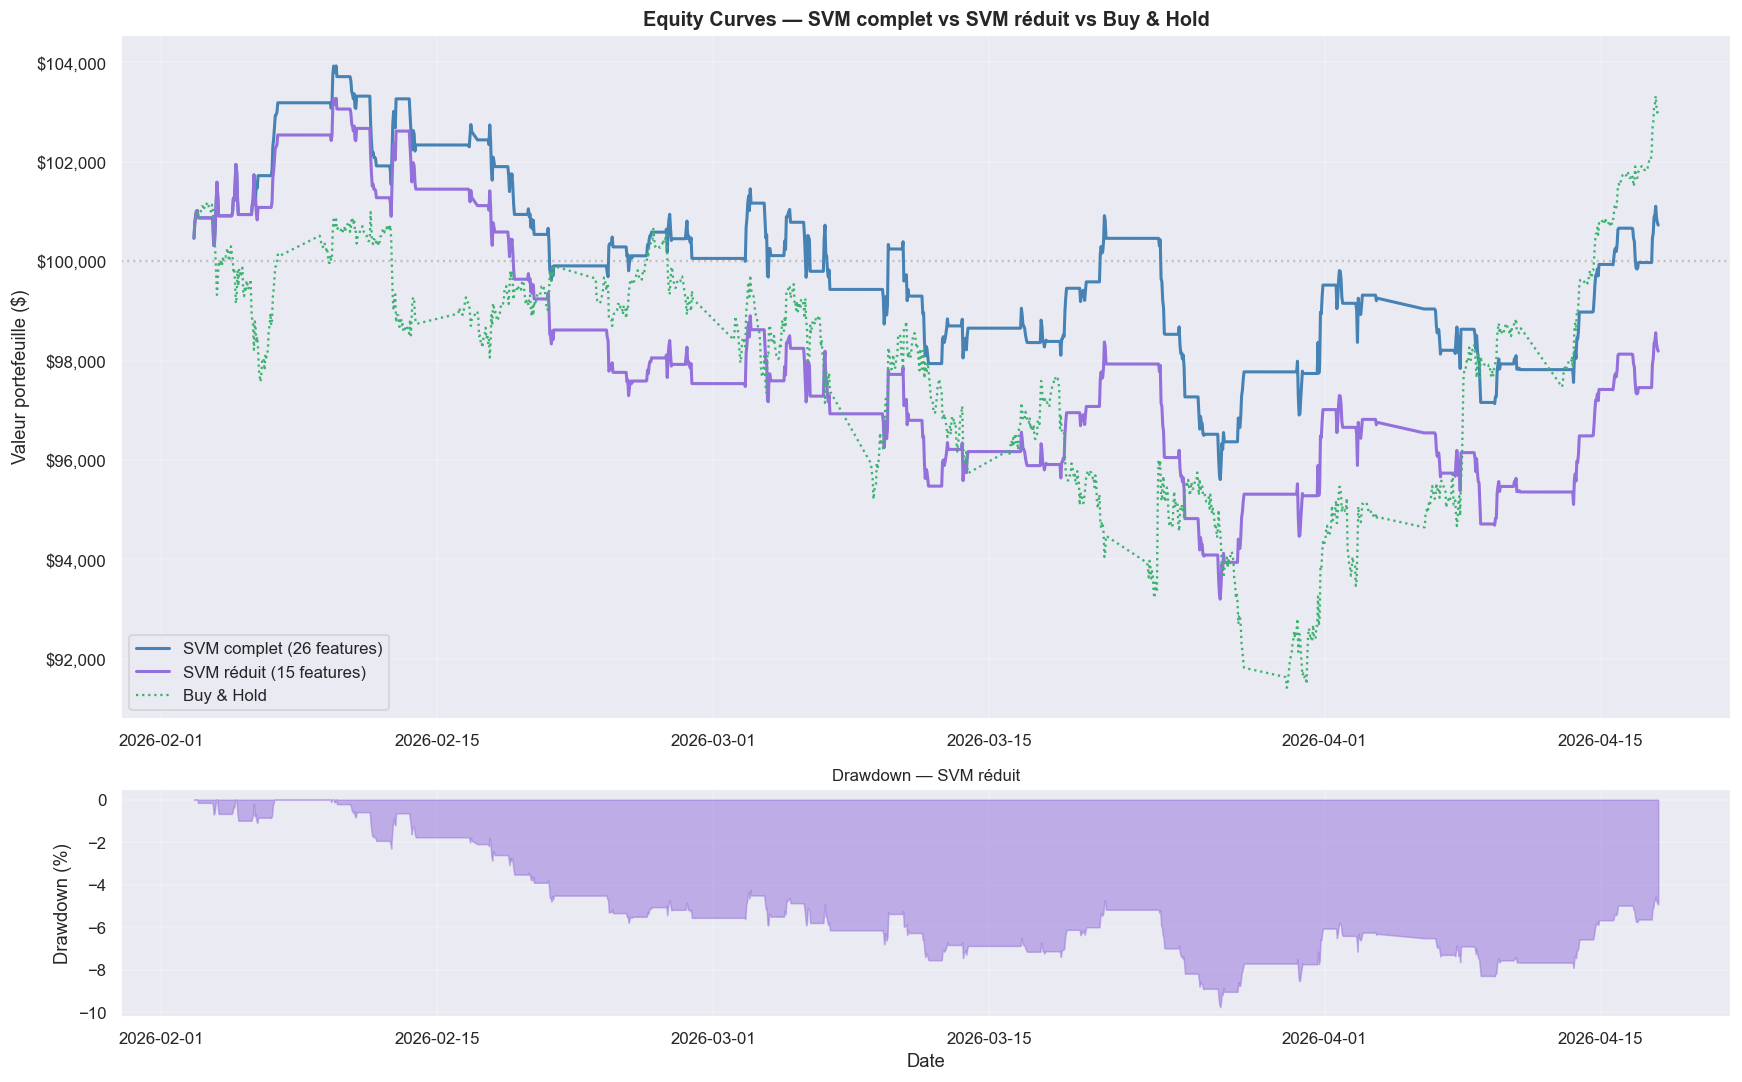

In [31]:
## 8d. Simulation de trading — SVM réduit (Top 15 features)

test_sim_top = test.copy()
test_sim_top['ml_signal'] = y_label_top

test_sim_top['heure']      = test_sim_top.index.hour
test_sim_top['session_us'] = (test_sim_top['heure'] >= 14) & (test_sim_top['heure'] <= 21)
test_sim_top['ml_signal_filtered'] = np.where(test_sim_top['session_us'], test_sim_top['ml_signal'], 0)

test_sim_top['ma10'] = test_sim_top['close'].rolling(10).mean()
test_sim_top.dropna(inplace=True)

test_sim_top['log_ret'] = np.log(test_sim_top['close'] / test_sim_top['close'].shift(1))
test_sim_top.dropna(inplace=True)

test_sim_top['change_ml'] = (test_sim_top['ml_signal_filtered'] != test_sim_top['ml_signal_filtered'].shift(1)).astype(int)

nb_trades_top = test_sim_top['change_ml'].sum()
print(f"Nombre de trades SVM réduit : {nb_trades_top:,} | Coût spread : {nb_trades_top * SPREAD_USD:,.2f} USD")

cout_spread_par_trade = SPREAD_USD / CAPITAL_INIT
test_sim_top['ret_ml_brut'] = test_sim_top['ml_signal_filtered'].shift(1) * test_sim_top['log_ret']
test_sim_top['ret_ml_net']  = test_sim_top['ret_ml_brut'] - (test_sim_top['change_ml'] * cout_spread_par_trade)
test_sim_top['ret_bh']      = test_sim_top['log_ret']
test_sim_top.dropna(inplace=True)

# ── SWAP overnight ────────────────────────────────────────────────────────
overnight_mask = test_sim_top.index.hour == 23
triple_mask    = test_sim_top.index.dayofweek == 4
mult           = np.where(triple_mask, 3, 1)
swap_long  = np.where(test_sim_top['ml_signal_filtered'] == 1,  CAPITAL_INIT * abs(SWAP_LONG_PCT)  * mult, 0)
swap_short = np.where(test_sim_top['ml_signal_filtered'] == -1, CAPITAL_INIT * abs(SWAP_SHORT_PCT) * mult, 0)
swap_cost_top = (swap_long + swap_short)[overnight_mask].sum()
print(f"Coût SWAP overnight : {swap_cost_top:,.2f} USD")

test_sim_top['equity_ml_net'] = CAPITAL_INIT * np.exp(test_sim_top['ret_ml_net'].cumsum())
test_sim_top['equity_bh']     = CAPITAL_INIT * np.exp(test_sim_top['ret_bh'].cumsum())
test_sim_top['equity_ml_net'] -= swap_cost_top / len(test_sim_top)

# ── Métriques ─────────────────────────────────────────────────────────────
m_top = compute_metrics(test_sim_top['ret_ml_net'], test_sim_top['equity_ml_net'])
m_bh  = compute_metrics(test_sim_top['ret_bh'],     test_sim_top['equity_bh'])

print("\n" + "="*65)
print("  COMPARAISON SVM complet (26) vs SVM réduit (15) vs Buy & Hold")
print("="*65)
print(f"{'Métrique':<28} {'SVM complet':>12} {'SVM réduit':>12} {'Buy & Hold':>12}")
print("-"*65)
print(f"{'Capital final ($)':<28} {m_ml['Capital final ($)']:>12,.0f} {m_top['Capital final ($)']:>12,.0f} {m_bh['Capital final ($)']:>12,.0f}")
print(f"{'Rendement annualisé (%)':<28} {m_ml['Rendement annualisé (%)']:>12.2f} {m_top['Rendement annualisé (%)']:>12.2f} {m_bh['Rendement annualisé (%)']:>12.2f}")
print(f"{'Max Drawdown (%)':<28} {m_ml['Max Drawdown (%)']:>12.2f} {m_top['Max Drawdown (%)']:>12.2f} {m_bh['Max Drawdown (%)']:>12.2f}")
print(f"{'Sharpe Ratio':<28} {m_ml['Sharpe Ratio']:>12.3f} {m_top['Sharpe Ratio']:>12.3f} {m_bh['Sharpe Ratio']:>12.3f}")
print("="*65)

# ── Graphique ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(test_sim['equity_ml_net'],     label='SVM complet (26 features)', color='steelblue',      linewidth=2)
axes[0].plot(test_sim_top['equity_ml_net'], label='SVM réduit (15 features)',   color='mediumpurple',   linewidth=2)
axes[0].plot(test_sim_top['equity_bh'],     label='Buy & Hold',                 color='mediumseagreen', linewidth=1.5, linestyle=':')
axes[0].axhline(CAPITAL_INIT, color='gray', linestyle=':', alpha=0.4)
axes[0].set_title('Equity Curves — SVM complet vs SVM réduit vs Buy & Hold', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valeur portefeuille ($)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

peak   = test_sim_top['equity_ml_net'].cummax()
dd_top = (test_sim_top['equity_ml_net'] - peak) / peak * 100
axes[1].fill_between(test_sim_top.index, dd_top, 0, color='mediumpurple', alpha=0.5)
axes[1].set_title('Drawdown — SVM réduit', fontsize=11)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Background dataset has 5827 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5827 when initializing the masker.


Computing SHAP values — LinearSVR...


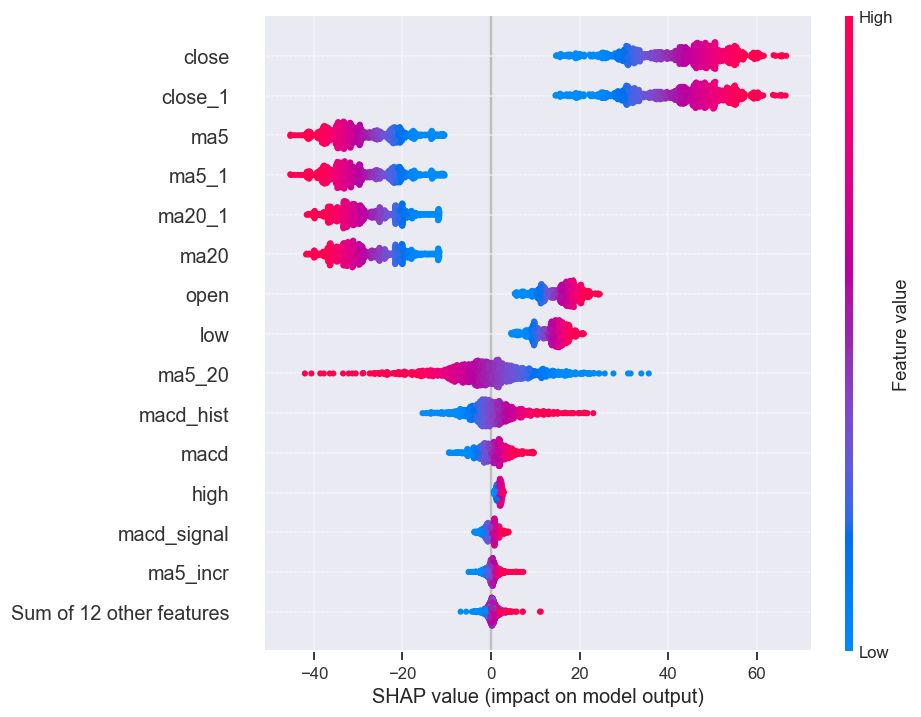

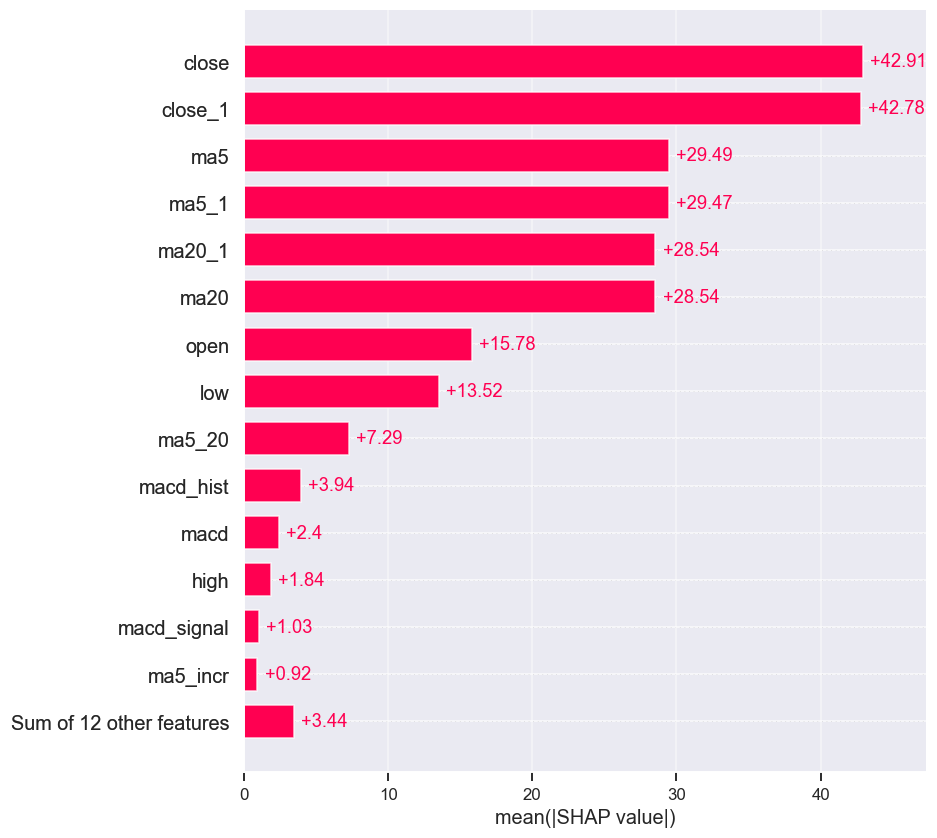

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape ()) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

<Figure size 1540x550 with 0 Axes>

In [34]:
## 8b. Feature Importance — SHAP (LinearSVR)

!pip install shap --quiet

import shap

print("Computing SHAP values — LinearSVR...")

explainer   = shap.LinearExplainer(reg_models['SVM'], X_train, feature_names=FEATURE_COLS)
shap_values = explainer(X_test)

# ── 1. Beeswarm ───────────────────────────────────────────────────────────
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=True)

# ── 2. Bar plot ───────────────────────────────────────────────────────────
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=True)

# ── 3. Waterfall — single observation ────────────────────────────────────
plt.figure()
shap.plots.waterfall(shap_values[0, 0], max_display=15, show=True)